# Syllable composition over the trial

Trial-aligned syllable histograms: one stacked column per time bin, showing what fraction of
trials were in each paw state at that moment. Same construction as fig 2A, drawn through
`paper_style` so the palette and the stacking order are shared.

Group the same plot by **session**, **mouse**, **trial type**, or **position along an LD
axis** — one knob. The LD grouping is the one that shows the individuality result directly:
LD3 is the laterality axis, so its extremes should come out blue (left) against orange
(right).

**Colour = paw**: hue is which forepaw leads, lightness is vigor (`ps.PAW_STATE_COLORS`).
**Whisk and lick** are proportions, drawn as a band and a line underneath — or, with
`TEXTURE = True`, laid over the stack as hatching.

In [1]:
# ---- SHARED FIGURE STYLE ------------------------------------------------------------
import sys, pathlib, importlib

_p = pathlib.Path.cwd().resolve()
while not (_p / 'paper_style.py').exists() and _p != _p.parent:
    _p = _p.parent
sys.path.insert(0, str(_p))
import paper_style
importlib.reload(paper_style)   # kernels cache modules; without this, edits stay invisible
ps = paper_style
ps.use('paper')                 # 'paper' = journal sizes; 'poster' = big type
ROOT = str(_p) + '/'

paper_style: paper mode, spines=lb, font 8 pt, panels 3.4x2.4 in, save 400 dpi


In [2]:
"""IMPORTS AND FILES"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# WHICH PAW-STATE SET the files below hold. It sets the syllable and states files, and through
# ps.use_paw_states() the palette, the vigor order, the side labels and the state profiles.
# Codes are translated into the set's numbering ONCE, where they are loaded (ps.paw_codes):
# the 'uniform' syllables carry 5_syllable_generation's old relabelling -- see paper_style.
STATE_SET = 'uniform'          # 'production' | 'uniform'
SYLLABLE_FILE = {'production': ROOT + 'data/8_k_10_bin_syllables_19-08-2026',
                 'uniform':    ROOT + 'data/8_k_10_bin_syllables_02-10-2026'}[STATE_SET]
STATES_FILES_DIR = {'production': ROOT + 'data/states_files_old_normalization/',
                    'uniform':    ROOT + 'data/states_files/'}[STATE_SET]
ps.use_paw_states(STATE_SET)
EMBEDDING = ROOT + 'clustering/data_files/mouse_LDA_5_bins_raw_shrink0.5_360_28-09-2026'
EPOCHS = ['Pre-quiescence', 'Quiescence', 'Choice', 'ITI']

# paw_bias moved from segmentation/ to vigor/; resolve it once instead of hardcoding
import os
PAW_BIAS_DIR = next(d for d in (ROOT + 'vigor/paw_bias/', ROOT + 'segmentation/paw_bias/')
                    if os.path.isdir(d))
TRIAL_FIELDS = ['feedback', 'contrast', 'block', 'side']   # the trial_type string, in order

## Knobs

`GROUP_BY` is the only one that changes what the figure is about.

| value | one panel per |
|---|---|
| `'session'` | the `N_GROUPS` sessions with most trials |
| `'mouse'` | a mouse, pooling all its sessions |
| `'trial_type'` | a level of `TRIAL_FIELD` |
| `'ld_extremes'` | a session sampled evenly along discriminant `LD` |

**`TRIAL_FIELD = 'side'` is a trap.** That field comes from the choice strings, which are
**mirrored** in this dataset — `'left'` is not the left side. Orient left/right on `'block'`
(probabilityLeft) instead. The knob still allows `'side'` because it is fine for asking
*whether* the two choice categories differ; just do not read the labels.

In [3]:
GROUP_BY    = 'session'   # 'session' | 'mouse' | 'trial_type' | 'ld_extremes'
N_GROUPS    = 5

TEXTURE     = True           # whisk (//) and lick (..) hatched OVER the stack, so one panel
                             # carries paw side, paw vigor, whisking and licking together.
                             # The panel is then widened automatically: a hatch needs
                             # ps.HATCH_MIN_PT per bin, which for 40 bins is ~6.7 in.
                             # False instead draws whisking and licking as proportions in a
                             # strip underneath, which stays legible at any width and keeps
                             # the laterality contrast louder -- texture splits most paw
                             # blocks in two, adding edges that are not paw transitions.

LD          = 3              # 1-indexed. LD3 is the laterality axis.
TRIAL_FIELD = 'block'        # feedback | contrast | block | side  -- read the note above
MIN_TRIALS  = 25             # a trial-type level below this is dropped rather than drawn
                             # from a handful of trials

In [4]:
"""LOAD"""
seq = pd.read_parquet(SYLLABLE_FILE)
seq['binned_sequence'] = seq['binned_sequence'].apply(ps.paw_codes)   # -> the set's numbering
seq['session'] = seq['sample'].str[:36]
emb = pd.read_pickle(EMBEDDING)
print(f"{seq['session'].nunique()} sessions, {seq['mouse_name'].nunique()} mice in the "
      f"syllable file; the embedding covers {len(emb)} of them")

FileNotFoundError: [Errno 2] No such file or directory: '/Users/ineslaranjeira/Documents/Repositories/representation_learning_variability/paper-individuality/data/8_k_10_bin_syllables_02-10-2026'

## What the eight states are

Before any composition plot, the two quantities the palette encodes, per state:

- **Vigor** — mean z-scored wavelet power over both forepaws, both image axes and the whole
  0.5–8 Hz band (`state_laterality()['overall']`). It sets **lightness**. Being a z-score it
  is relative, so the quiet states are negative rather than zero, and because it averages
  across frequencies it is *total power*, not speed: state 2 is slow and large, state 3 fast
  and small, and they land at similar vigor.
- **Left − right gap** — the absolute asymmetry between the paws. It sets **chroma**, and
  the sign sets **hue**. Deliberately not the laterality index `LI = (L−R)/(|L|+|R|)`, whose
  denominator collapses for the quiet states and turns state 1's 0.045 gap into LI +0.13.

Occupancy is shown alongside because it is what makes the extremes readable in context:
state 7 has by far the largest vigor but is 0.7% of bins, so it is a rare flourish rather
than something a session is made of.

States are ordered by vigor, not by their HMM numbers, which are arbitrary — see
`ps.PAW_VIGOR_ORDER`.

not saved (ps.SAVE_FIGURES is False): figures/paw_state_characterisation_02-10-2026.png, figures/paw_state_characterisation_02-10-2026.svg   -- ps.saving(True) to write, or pass save=True


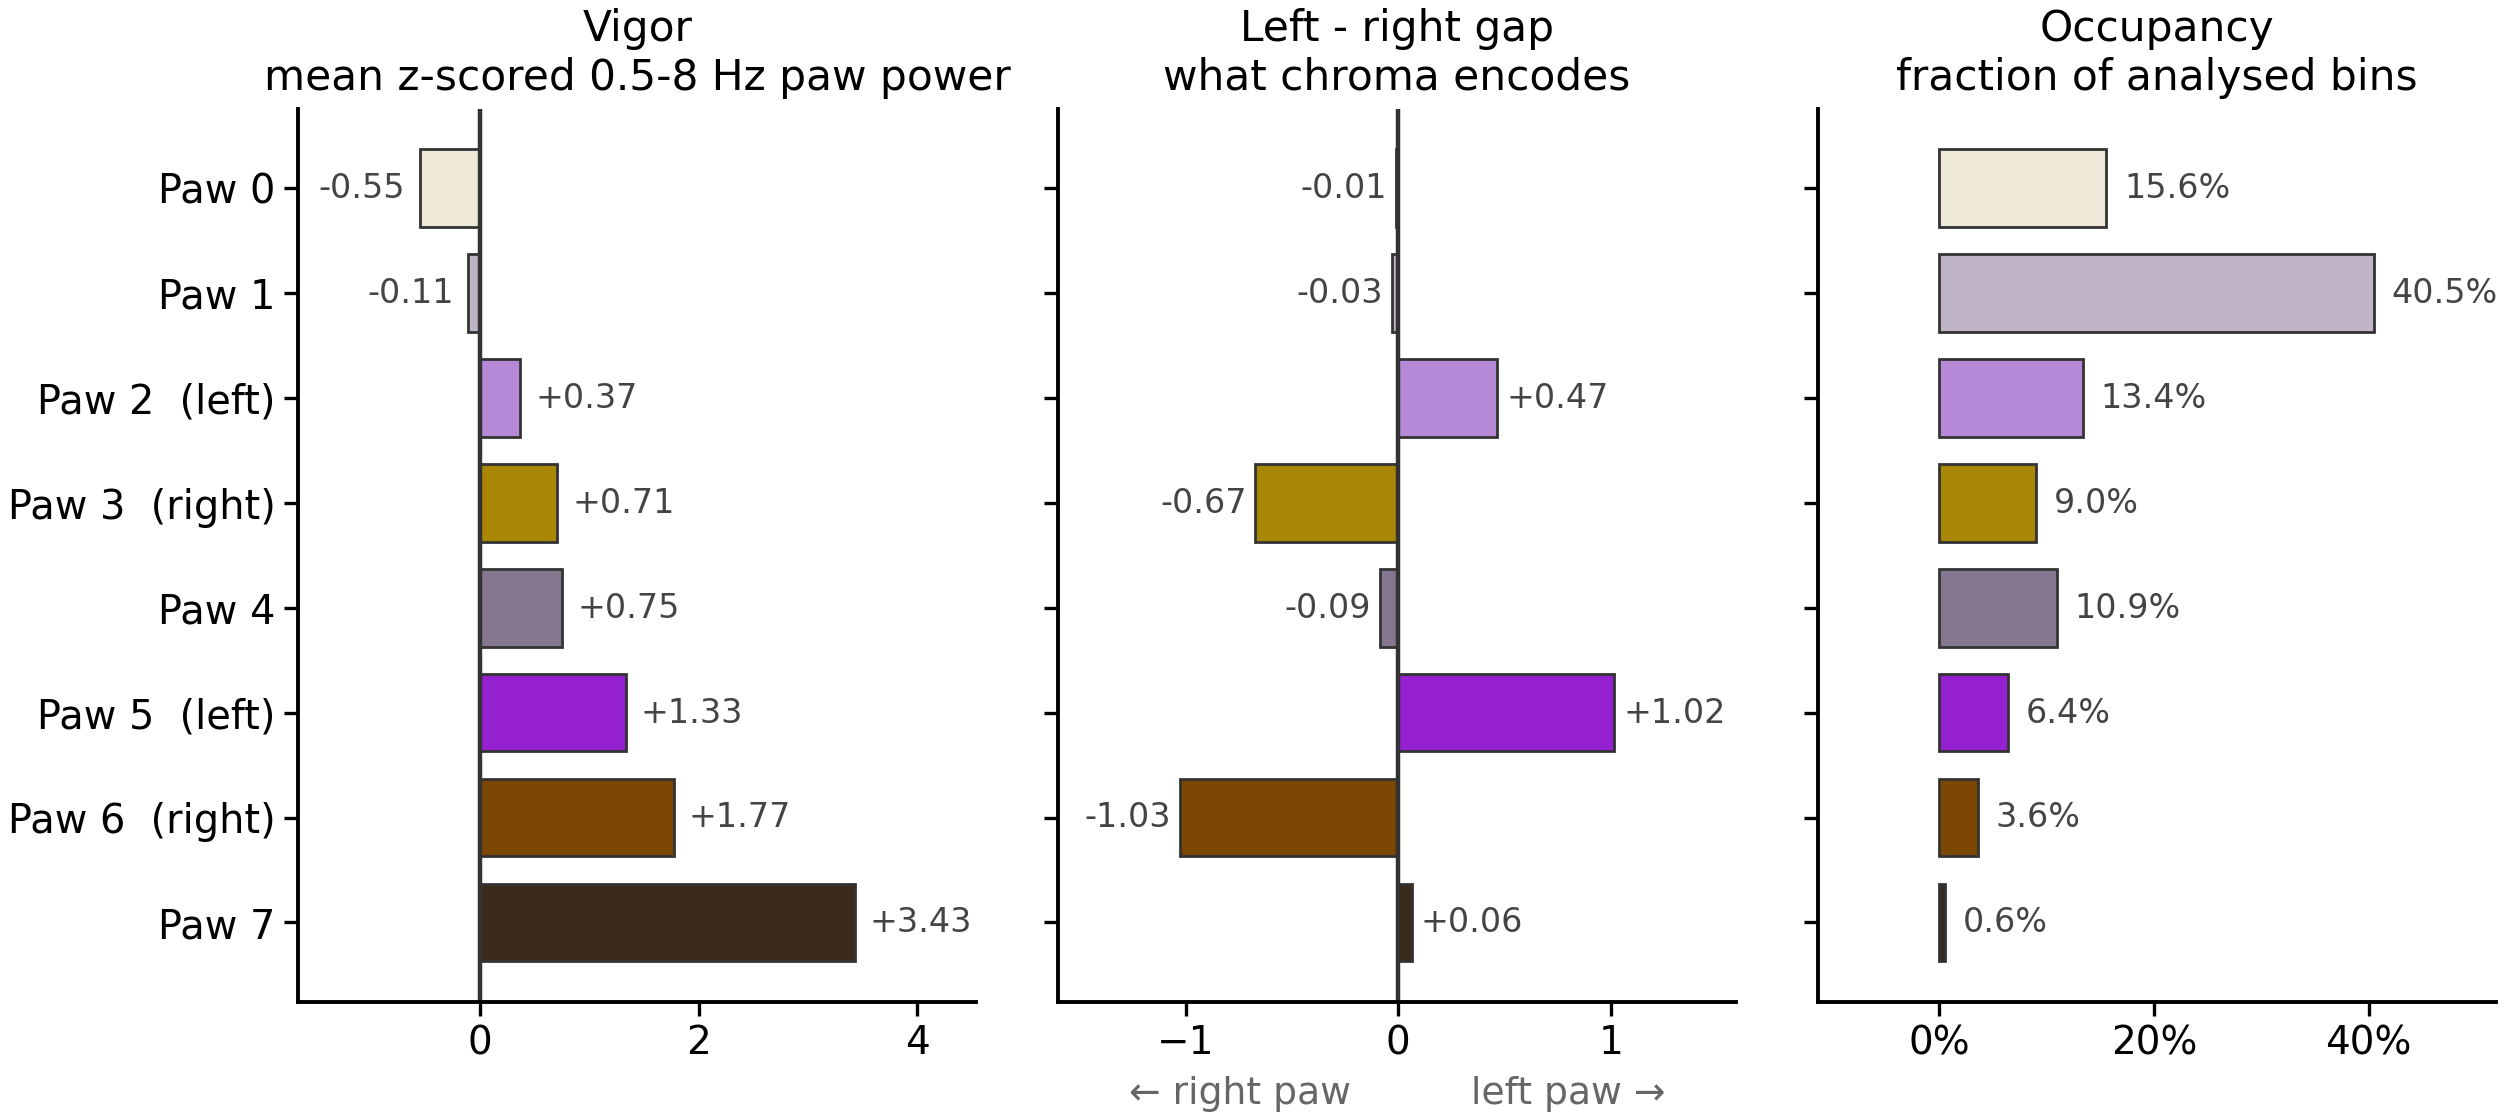

In [ ]:
"""THE EIGHT STATES, CHARACTERISED -- vigor and left-right gap, in the palette itself."""
import sys, os
# laterality_features moved from 4_mice/laterality to vigor/laterality; try both rather
# than hardcoding whichever is current, so this cell survives the next reorganisation
for _cand in (ROOT + 'vigor/laterality', ROOT + '4_mice/laterality'):
    if os.path.isfile(_cand + '/laterality_features.py'):
        sys.path.insert(0, _cand)
        break
else:
    raise FileNotFoundError('laterality_features.py not found under ROOT')
from laterality_features import state_laterality

# recomputed from the state wavelet profiles, never hardcoded, so a refit of the clustering
# changes this figure and the palette together
S = state_laterality(ps.paw_profiles(ROOT))   # the active state set's profiles
S['gap'] = S['left'] - S['right']

# occupancy from THE FILE THIS NOTEBOOK USES, not the supersession the HMM was fit on --
# they differ (state 0 is 35.7% of all frames but 12.1% of the analysed trial bins), and the
# relevant one is what these panels actually draw
_all = np.concatenate(seq['binned_sequence'].to_numpy())
_paw = _all[~np.isnan(_all)].astype(int) % ps.N_PAW_STATES
S['occ'] = np.bincount(_paw, minlength=ps.N_PAW_STATES) / len(_paw)

order = list(ps.PAW_VIGOR_ORDER)
ypos = -np.arange(len(order))
bar_colors = [ps.PAW_STATE_COLORS[s] for s in order]

PANELS = [('overall', 'Vigor\nmean z-scored 0.5-8 Hz paw power', True),
          ('gap',     'Left - right gap\nwhat chroma encodes',   True),
          ('occ',     'Occupancy\nfraction of analysed bins',    False)]

fig, axes = plt.subplots(1, 3, figsize=(ps.FIG['double'][0], 2.9), sharey=True,
                         gridspec_kw=dict(wspace=0.12))
for ax, (col, title, diverging) in zip(axes, PANELS):
    vals = [S[col][s] for s in order]
    # a thin dark edge, because the pale states would otherwise have no visible bar
    ax.barh(ypos, vals, height=0.74, color=bar_colors, edgecolor='#333333', linewidth=0.5)
    if diverging:
        ax.axvline(0, color='#333333', lw=0.8)
    ax.set_title(title, fontsize=plt.rcParams['font.size'] * 0.95)
    ax.spines[['top', 'right']].set_visible(False)
    for y, v in zip(ypos, vals):
        ax.text(v + (0.04 if v >= 0 else -0.04) * max(abs(np.array(vals))), y,
                f'{v:+.2f}' if diverging else f'{v:.1%}',
                va='center', ha='left' if v >= 0 else 'right',
                fontsize=plt.rcParams['font.size'] * 0.75, color='#444')
    lo, hi = min(vals + [0]), max(vals + [0])
    ax.set_xlim(lo - 0.28 * (hi - lo), hi + 0.28 * (hi - lo))

axes[0].set_yticks(ypos)
axes[0].set_yticklabels([ps.paw_label(s) for s in order],
                        fontsize=plt.rcParams['font.size'] * 0.9)
axes[1].set_xlabel('\u2190 right paw          left paw \u2192',
                   fontsize=plt.rcParams['font.size'] * 0.85, color='#666')
axes[2].xaxis.set_major_formatter(lambda x, _: f'{x:.0%}')
# fig.suptitle('The eight paw states, ordered by vigor', y=1.04)

ps.savefig(fig, 'paw_state_characterisation', svg=True)   # ps.saving(True) to write
plt.show()

### The two paws side by side, band by band

Each paw on its own, and now resolved into the five wavelet bands rather than averaged into
one number. Reading across the panels is how the palette was built: Paw 3 and 5 sit higher on
the left, Paw 4 and 6 higher on the right, and 0, 1, 2, 7 are near-symmetric — which is why
the first four carry hue and the rest are close to neutral.

**The spectrum shape is what the single vigor number throws away.** Two states can have the
same total power and be completely different movements:

- **2 and 7 fall with frequency** — large, slow movement. State 7 is the most powerful state
  in the set but almost all of it is at 0.5–1 Hz.
- **3, 5 and 6 rise with frequency** — small, fast movement. State 5 nearly doubles from
  0.5 to 8 Hz on the left paw, state 6 does the same on the right.

So lightness in the palette means *total* 0.5–8 Hz power, not speed. If a state's character
matters for how you describe it in text, read it off this figure rather than off vigor.

Both wavelet axes (x and y) are averaged, the same convention the vigor and gap panels use.

not saved (ps.SAVE_FIGURES is False): figures/paw_state_spectrum_02-10-2026.png, figures/paw_state_spectrum_02-10-2026.svg   -- ps.saving(True) to write, or pass save=True


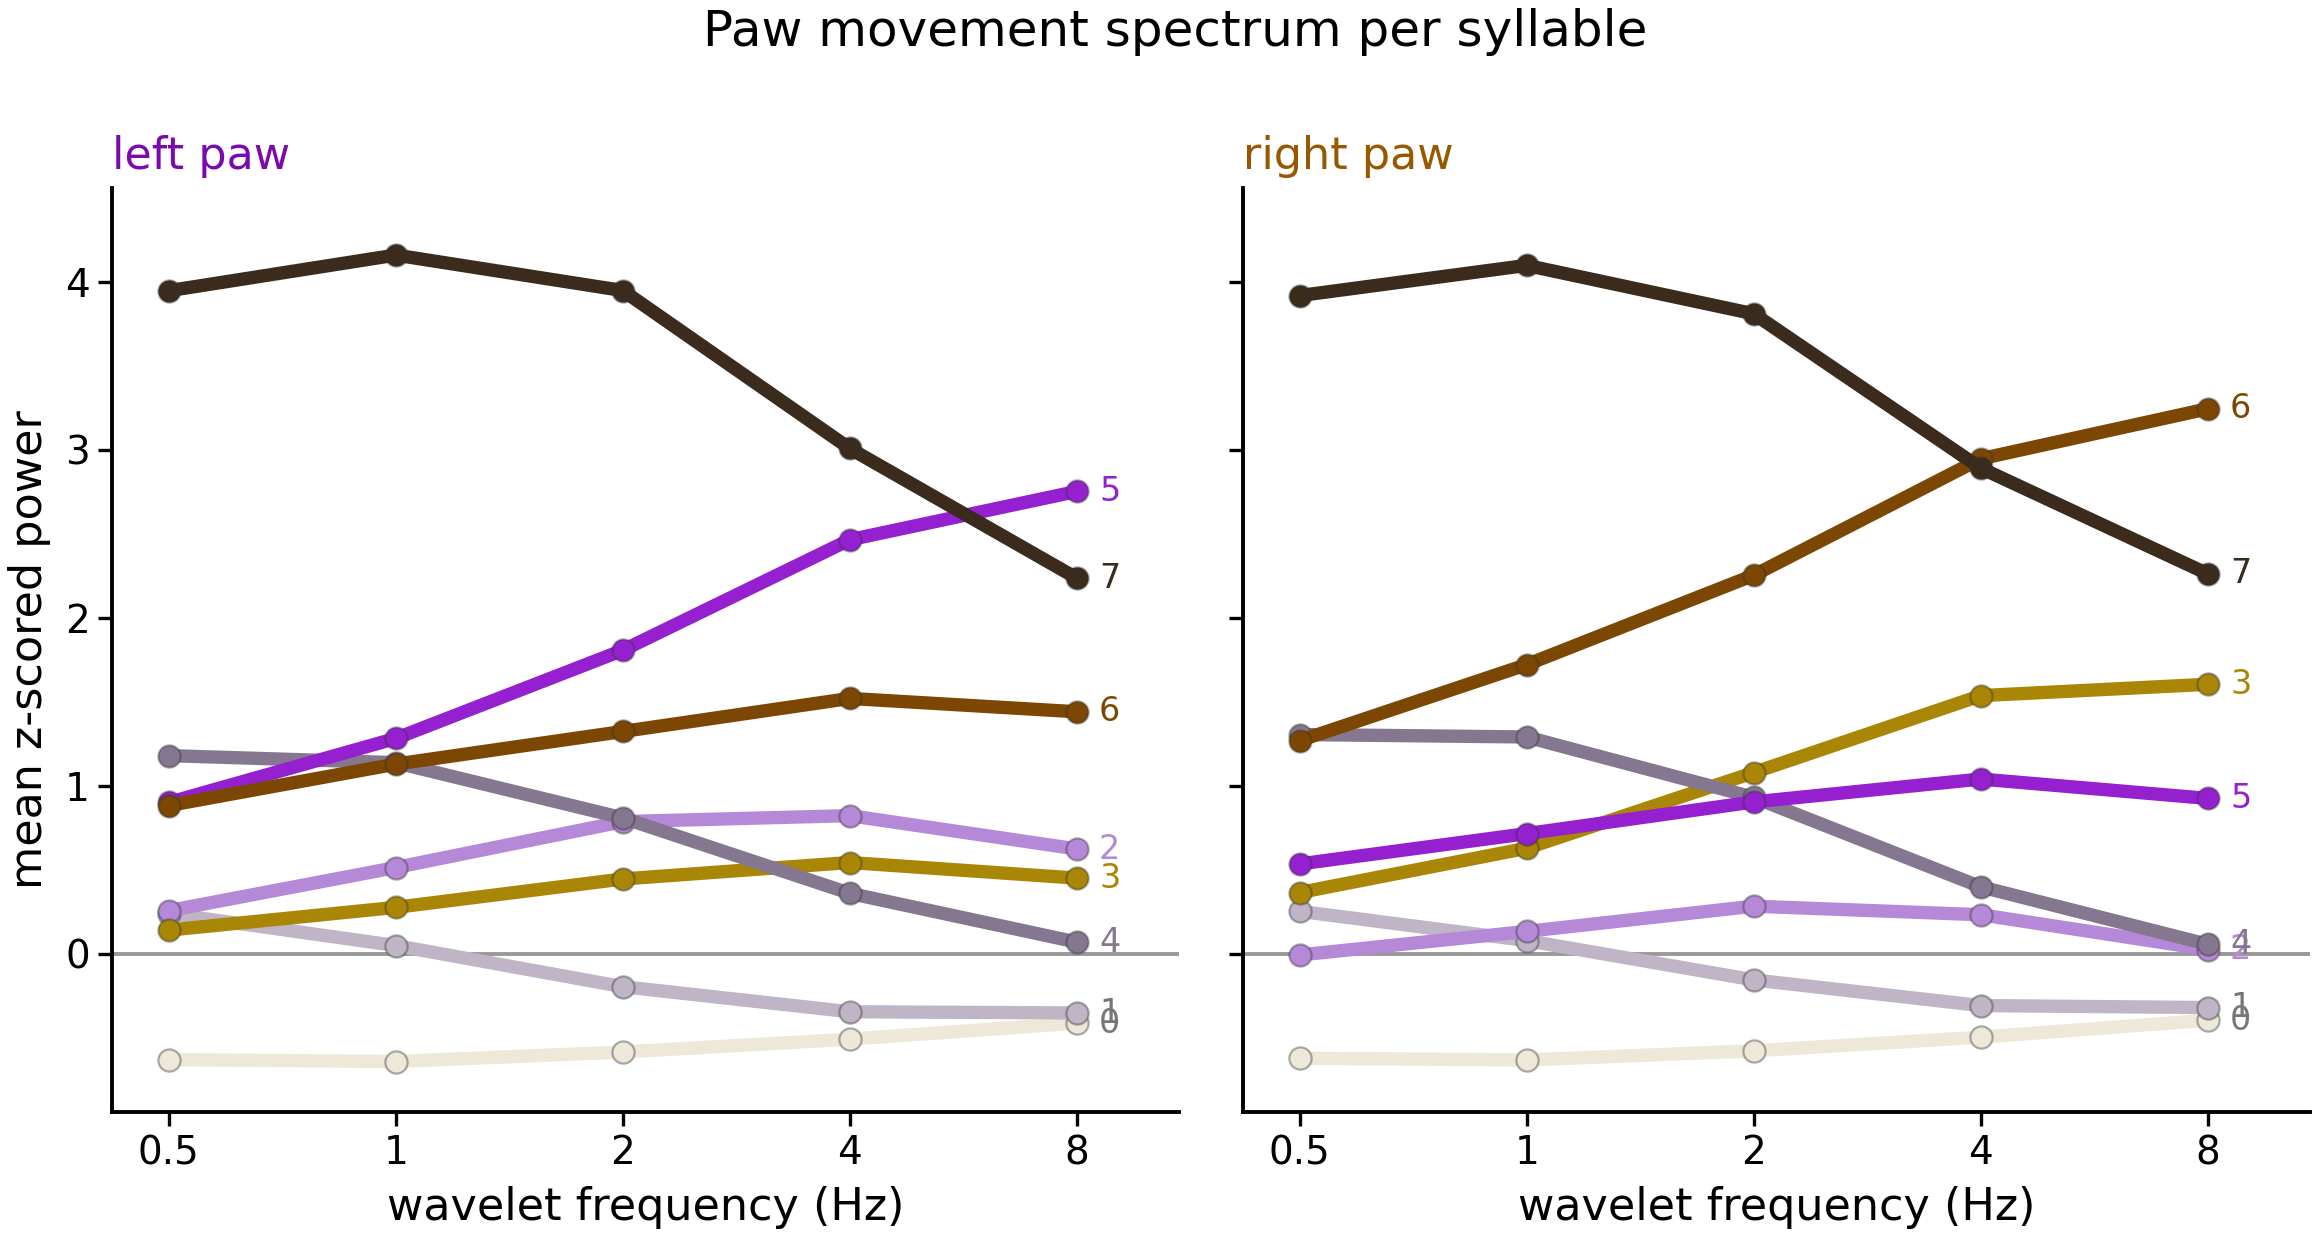

In [ ]:
"""PAW MOVEMENT SPECTRUM PER SYLLABLE -- one panel per paw, one point per band."""
_prof = ps.paw_profiles(ROOT)        # the active state set's profiles
FREQS = [0.5, 1.0, 2.0, 4.0, 8.0]          # the wavelet bands the profile table carries


def band_power(paw, f):
    """Mean z-scored power for one paw in one band, x and y averaged."""
    return _prof[[f'{paw}_paw_x{f}', f'{paw}_paw_y{f}']].mean(axis=1)


spectrum = {p: pd.DataFrame({f: band_power(p, f) for f in FREQS}) for p in ('l', 'r')}

_x = np.arange(len(FREQS))
_lo = min(spectrum['l'].values.min(), spectrum['r'].values.min())
_hi = max(spectrum['l'].values.max(), spectrum['r'].values.max())

# ONE y scale across both panels. Autoscaling each would make the two paws look equally
# active in every state, which is the thing this figure exists to disprove.
fig, axes = plt.subplots(1, 2, figsize=(ps.FIG['double'][0], 3.0), sharey=True,
                         gridspec_kw=dict(wspace=0.06))
for ax, (p, name, accent) in zip(axes, [('l', 'left paw', ps.PAW_LEFT),
                                        ('r', 'right paw', ps.PAW_RIGHT)]):
    ax.axhline(0, color='#999999', lw=0.7)
    for s in order:
        y = spectrum[p].loc[s].to_numpy()
        ax.plot(_x, y, color=ps.PAW_STATE_COLORS[s], lw=2.4, marker='o', ms=4,
                markeredgecolor='#33333366', markeredgewidth=0.4)
        # direct-labelled at the right edge; a legend for 8 near-neutral lines is unreadable
        ax.annotate(str(s), (_x[-1], y[-1]), xytext=(4, 0), textcoords='offset points',
                    va='center', fontsize=plt.rcParams['font.size'] * 0.75,
                    color=ps.PAW_STATE_COLORS[s] if s not in (0, 1) else '#777')
    ax.set_xticks(_x)
    ax.set_xticklabels([f'{f:g}' for f in FREQS])
    ax.set_xlim(-0.25, len(FREQS) - 0.55)
    ax.set_ylim(_lo - 0.3, _hi + 0.4)
    ax.set_xlabel('wavelet frequency (Hz)')
    ax.set_title(name, fontsize=plt.rcParams['font.size'], color=accent, loc='left')
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel('mean z-scored power')
fig.suptitle('Paw movement spectrum per syllable', y=1.03)

ps.savefig(fig, 'paw_state_spectrum', svg=True)   # ps.saving(True) to write
plt.show()

### Where the wavelets come from

The same snippet figure as the end of `1_segmentation/1_b.ipynb`, drawn in the paw palette so
the two notebooks agree about which paw is which: **violet = left, amber = right**, with the
frequency ladder as tints of each.

Top panel is raw horizontal paw position; bottom is its wavelet decomposition at 1, 2, 4 and
8 Hz — the quantity every other figure here is built on. It is worth seeing once, because the
state profiles, the vigor ordering and the left–right gap are all summaries of *this*.

Two departures from 1_b, both for legibility rather than content:

- **Stacked panels instead of twin y axes.** Ten traces on two scales in one frame is not
  readable; position and power get a panel each, sharing the x axis.
- **The window is chosen, not the first 500 samples** — the most active window in the
  session, so the snippet shows movement rather than whatever the recording opened with.

`l_paw_x` is halved throughout: the left camera is 1280×1024 against the right's 640×512, so
its pixels are twice the size. That is the same correction `get_speed` applies, and the
`paw_bias` README documents what happens when it is forgotten — it equates spatial scale but
also halves the left camera's tracking noise, which is the origin of the right-paw amplitude
artefact.

  CSH_ZAD_029 064a7252, window 1502-1511 s of 70 min
not saved (ps.SAVE_FIGURES is False): figures/paw_wavelet_snippet_02-10-2026.png, figures/paw_wavelet_snippet_02-10-2026.svg   -- ps.saving(True) to write, or pass save=True


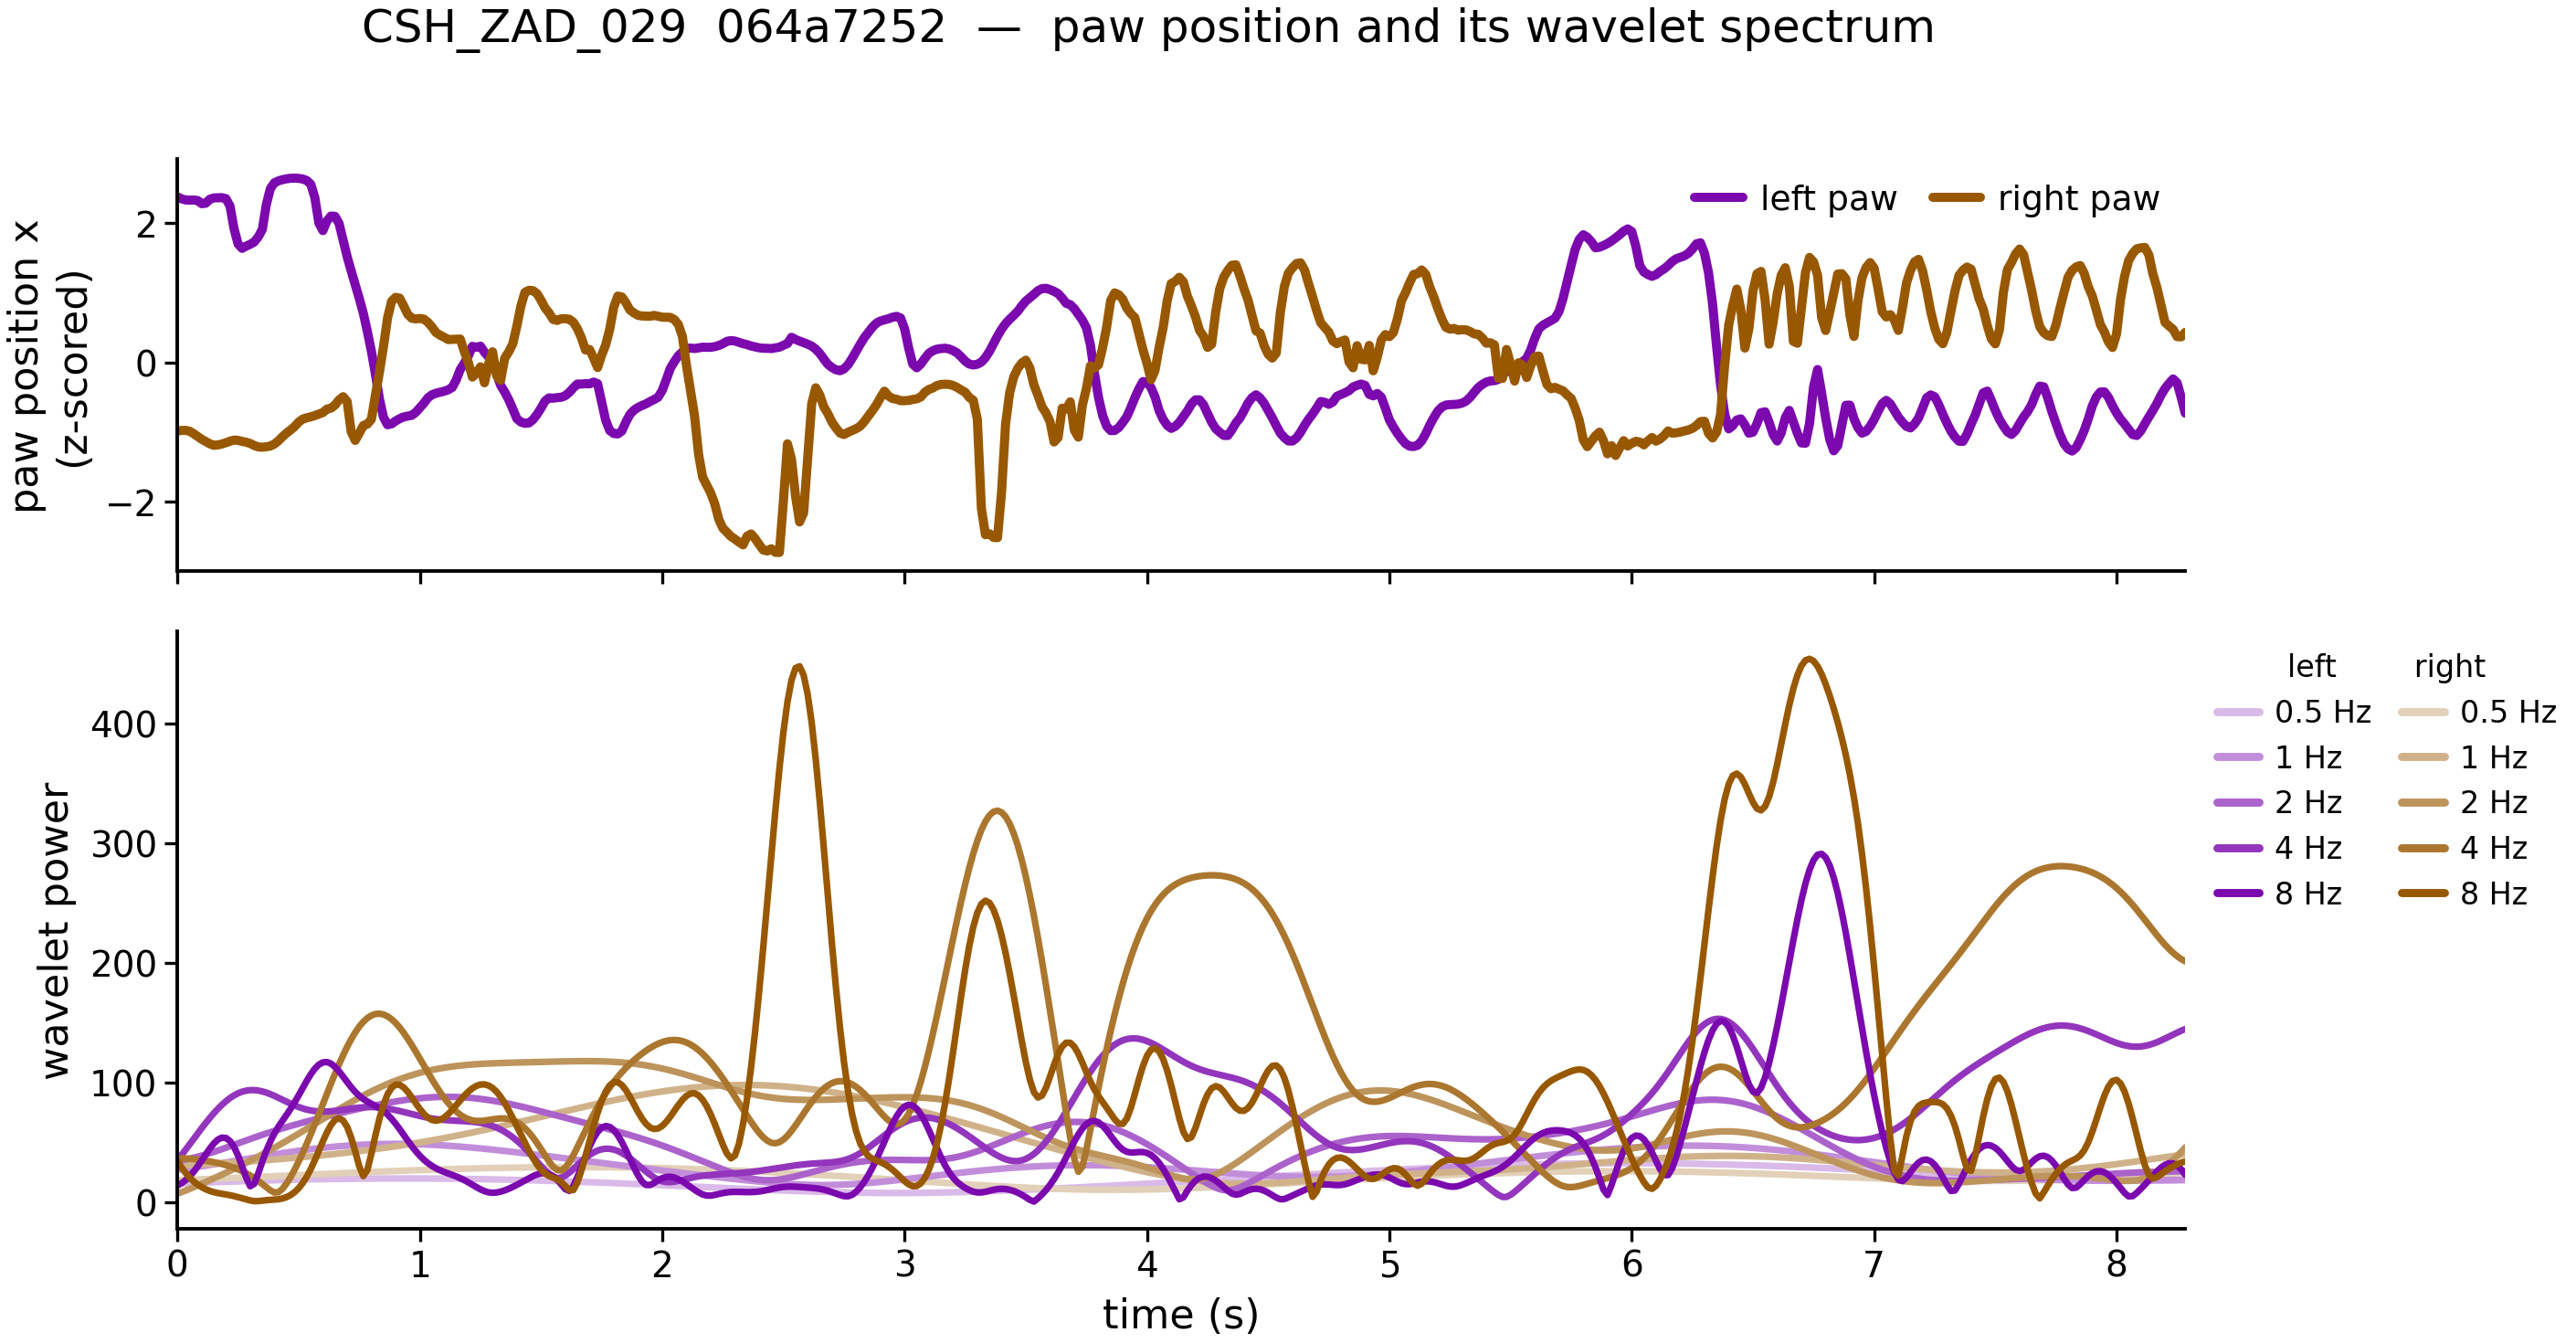

In [ ]:
"""A SNIPPET OF PAW POSITION AND ITS WAVELET SPECTRUM."""
import glob, os
from matplotlib.colors import to_rgb
from matplotlib.lines import Line2D

SNIPPET_FREQS   = [0.5, 1.0, 2.0, 4.0, 8.0]   # 0.5, 16 and 32 Hz dropped, as in 1_b
SNIPPET_SECONDS = 8.3
SNIPPET_SESSION = None                   # None = the first session with wavelets AND an embedding
FS = 60.0                                # camera sampling rate

_wav = {os.path.basename(f).split('_')[3]: f
        for f in glob.glob(ROOT + 'data/paw_wavelets/*/paw_vel_wavelets_*')}
_shared = sorted(set(_wav) & set(emb['session']))
assert _shared, 'no session has both paw wavelets and an LDA embedding'
_sess = SNIPPET_SESSION or _shared[0]
_row = emb[emb['session'] == _sess].iloc[0]

_cols = (['l_paw_x', 'r_paw_x']
         + [f'{p}_paw_x{f}' for p in ('l', 'r') for f in SNIPPET_FREQS])
_D = pd.read_parquet(_wav[_sess])[_cols].dropna().to_numpy()

# THE MOST ACTIVE WINDOW, not the first. The recording opens with the mouse often still, and
# a snippet of a quiet stretch shows nothing about what the wavelets are decomposing.
_w = int(SNIPPET_SECONDS * FS)
_act = [np.nanstd(_D[i:i + _w, 0]) + np.nanstd(_D[i:i + _w, 1])
        for i in range(0, len(_D) - _w, _w)]
_s0 = int(np.argmax(_act)) * _w
d = _D[_s0:_s0 + _w]
t = np.arange(len(d)) / FS


def freq_ramp(hexcol, n, lightest=0.72):
    """n tints of ONE hue, light to full -- the frequency ladder within a paw."""
    base = np.array(to_rgb(hexcol))
    return [tuple(base * (1 - f) + f) for f in np.linspace(lightest, 0.0, n)]


Lr, Rr = freq_ramp(ps.PAW_LEFT, len(SNIPPET_FREQS)), freq_ramp(ps.PAW_RIGHT, len(SNIPPET_FREQS))

fig, (axp, axw) = plt.subplots(2, 1, sharex=True, figsize=(ps.FIG['double'][0], 3.8),
                               gridspec_kw=dict(height_ratios=[1, 1.45], hspace=0.12))
_z = lambda v: (v - v.mean()) / v.std()
# l_paw_x halved -- see the note above
axp.plot(t, _z(d[:, 0] / 2), color=ps.PAW_LEFT, lw=1.8, label='left paw')
axp.plot(t, _z(d[:, 1]), color=ps.PAW_RIGHT, lw=1.8, label='right paw')
axp.set_ylabel('paw position x\n(z-scored)')
axp.legend(fontsize=plt.rcParams['font.size'] * 0.85, frameon=False, ncol=2, loc='upper right')
axp.spines[['top', 'right']].set_visible(False)

for i in range(len(SNIPPET_FREQS)):
    axw.plot(t, d[:, 2 + i], color=Lr[i], lw=1.3)
    axw.plot(t, d[:, 2 + len(SNIPPET_FREQS) + i], color=Rr[i], lw=1.3)
axw.set_ylabel('wavelet power')
axw.set_xlabel('time (s)')
axw.set_xlim(t[0], t[-1])
axw.spines[['top', 'right']].set_visible(False)
axw.legend(handles=[Line2D([], [], color=Lr[i], lw=1.6, label=f'{f:g} Hz')
                    for i, f in enumerate(SNIPPET_FREQS)]
                 + [Line2D([], [], color=Rr[i], lw=1.6, label=f'{f:g} Hz')
                    for i, f in enumerate(SNIPPET_FREQS)],
           ncol=2, fontsize=plt.rcParams['font.size'] * 0.75, frameon=False,
           bbox_to_anchor=(1.005, 1), loc='upper left',
           title='left        right', title_fontsize=plt.rcParams['font.size'] * 0.75)

fig.suptitle(f'{_row["mouse_name"]}  {_sess[:8]}  \u2014  paw position and its wavelet spectrum',
             y=0.99)
print(f'  {_row["mouse_name"]} {_sess[:8]}, window {_s0 / FS:.0f}-{(_s0 + _w) / FS:.0f} s '
      f'of {len(_D) / FS / 60:.0f} min')

ps.savefig(fig, 'paw_wavelet_snippet', svg=True)   # ps.saving(True) to write
plt.show()

### The three channels and the states fit to them

One window of raw recording, three channels stacked, each trace drawn **on top of its own
state sequence as a background band**. This is the segmentation shown as segmentation: the
colour behind the line is what every other panel in this notebook counts, and here it sits
directly under the signal it was fit to.

| row | trace | background band |
|---|---|---|
| paw | horizontal position of each forepaw, z-scored | the 8-state paw HMM, in the shared palette |
| whisk | whisker motion energy | whisking / not |
| lick | lick count per bin | licking / not |

**Position is drawn, but the states see velocity.** The wavelets the clustering runs on are
computed from *velocity* (`get_speed(..., split=True)`), so a band boundary marks a change in
how fast the paw is moving, not where it is — a state can change while the trace sits still
on the page, and that is correct rather than a misalignment. Position is shown because it is
far easier to read than a speed trace of spikes; `PAW_TRACE = 'speed'` switches to the
quantity the states actually see.

**z-scored per session, not per window**, so the y axis means "SD from this session's mean
position" and a window can legitimately sit off-centre. Note this makes the usual `l_paw / 2`
correction for the left camera's 2× resolution a no-op — a z-score is scale-invariant — so it
matters for `PAW_TRACE = 'speed'` and cancels here.

**Two things keep the line readable over the colour.** The bands are drawn at
`STATE_ALPHA`, and each trace carries a white outline — necessary because the paw traces use
the *same two hues* as the paw states (violet = left, amber = right), so an unoutlined amber
line vanishes inside an amber band. Raise `STATE_ALPHA` if you want the states louder.

**The window is chosen for state diversity, not for activity.** Picking the most *active*
window selects the session's extreme, which lands almost entirely in paw state 7 — 0.7% of
bins overall, so the snippet would misrepresent the segmentation. The score below is the
entropy of the paw-state distribution, with whisking and licking each required to occur and
not occur, which is what makes all three rows worth looking at. Set `TRISTRIP_START` to a
time in seconds to override.

Dotted vertical lines are go cues, for orientation only.


/tmp/ipykernel_122750/3459436251.py:60: RuntimeWarning: divide by zero encountered in log
  return float(-np.sum(np.where(c > 0, c * np.log(c), 0.0)))
/tmp/ipykernel_122750/3459436251.py:60: RuntimeWarning: invalid value encountered in multiply
  return float(-np.sum(np.where(c > 0, c * np.log(c), 0.0)))


  position; window 300–320 s of 70 min; paw-state entropy 1.64 nats
not saved (ps.SAVE_FIGURES is False): figures/syllable_channel_snippet_02-10-2026.png, figures/syllable_channel_snippet_02-10-2026.svg   -- ps.saving(True) to write, or pass save=True


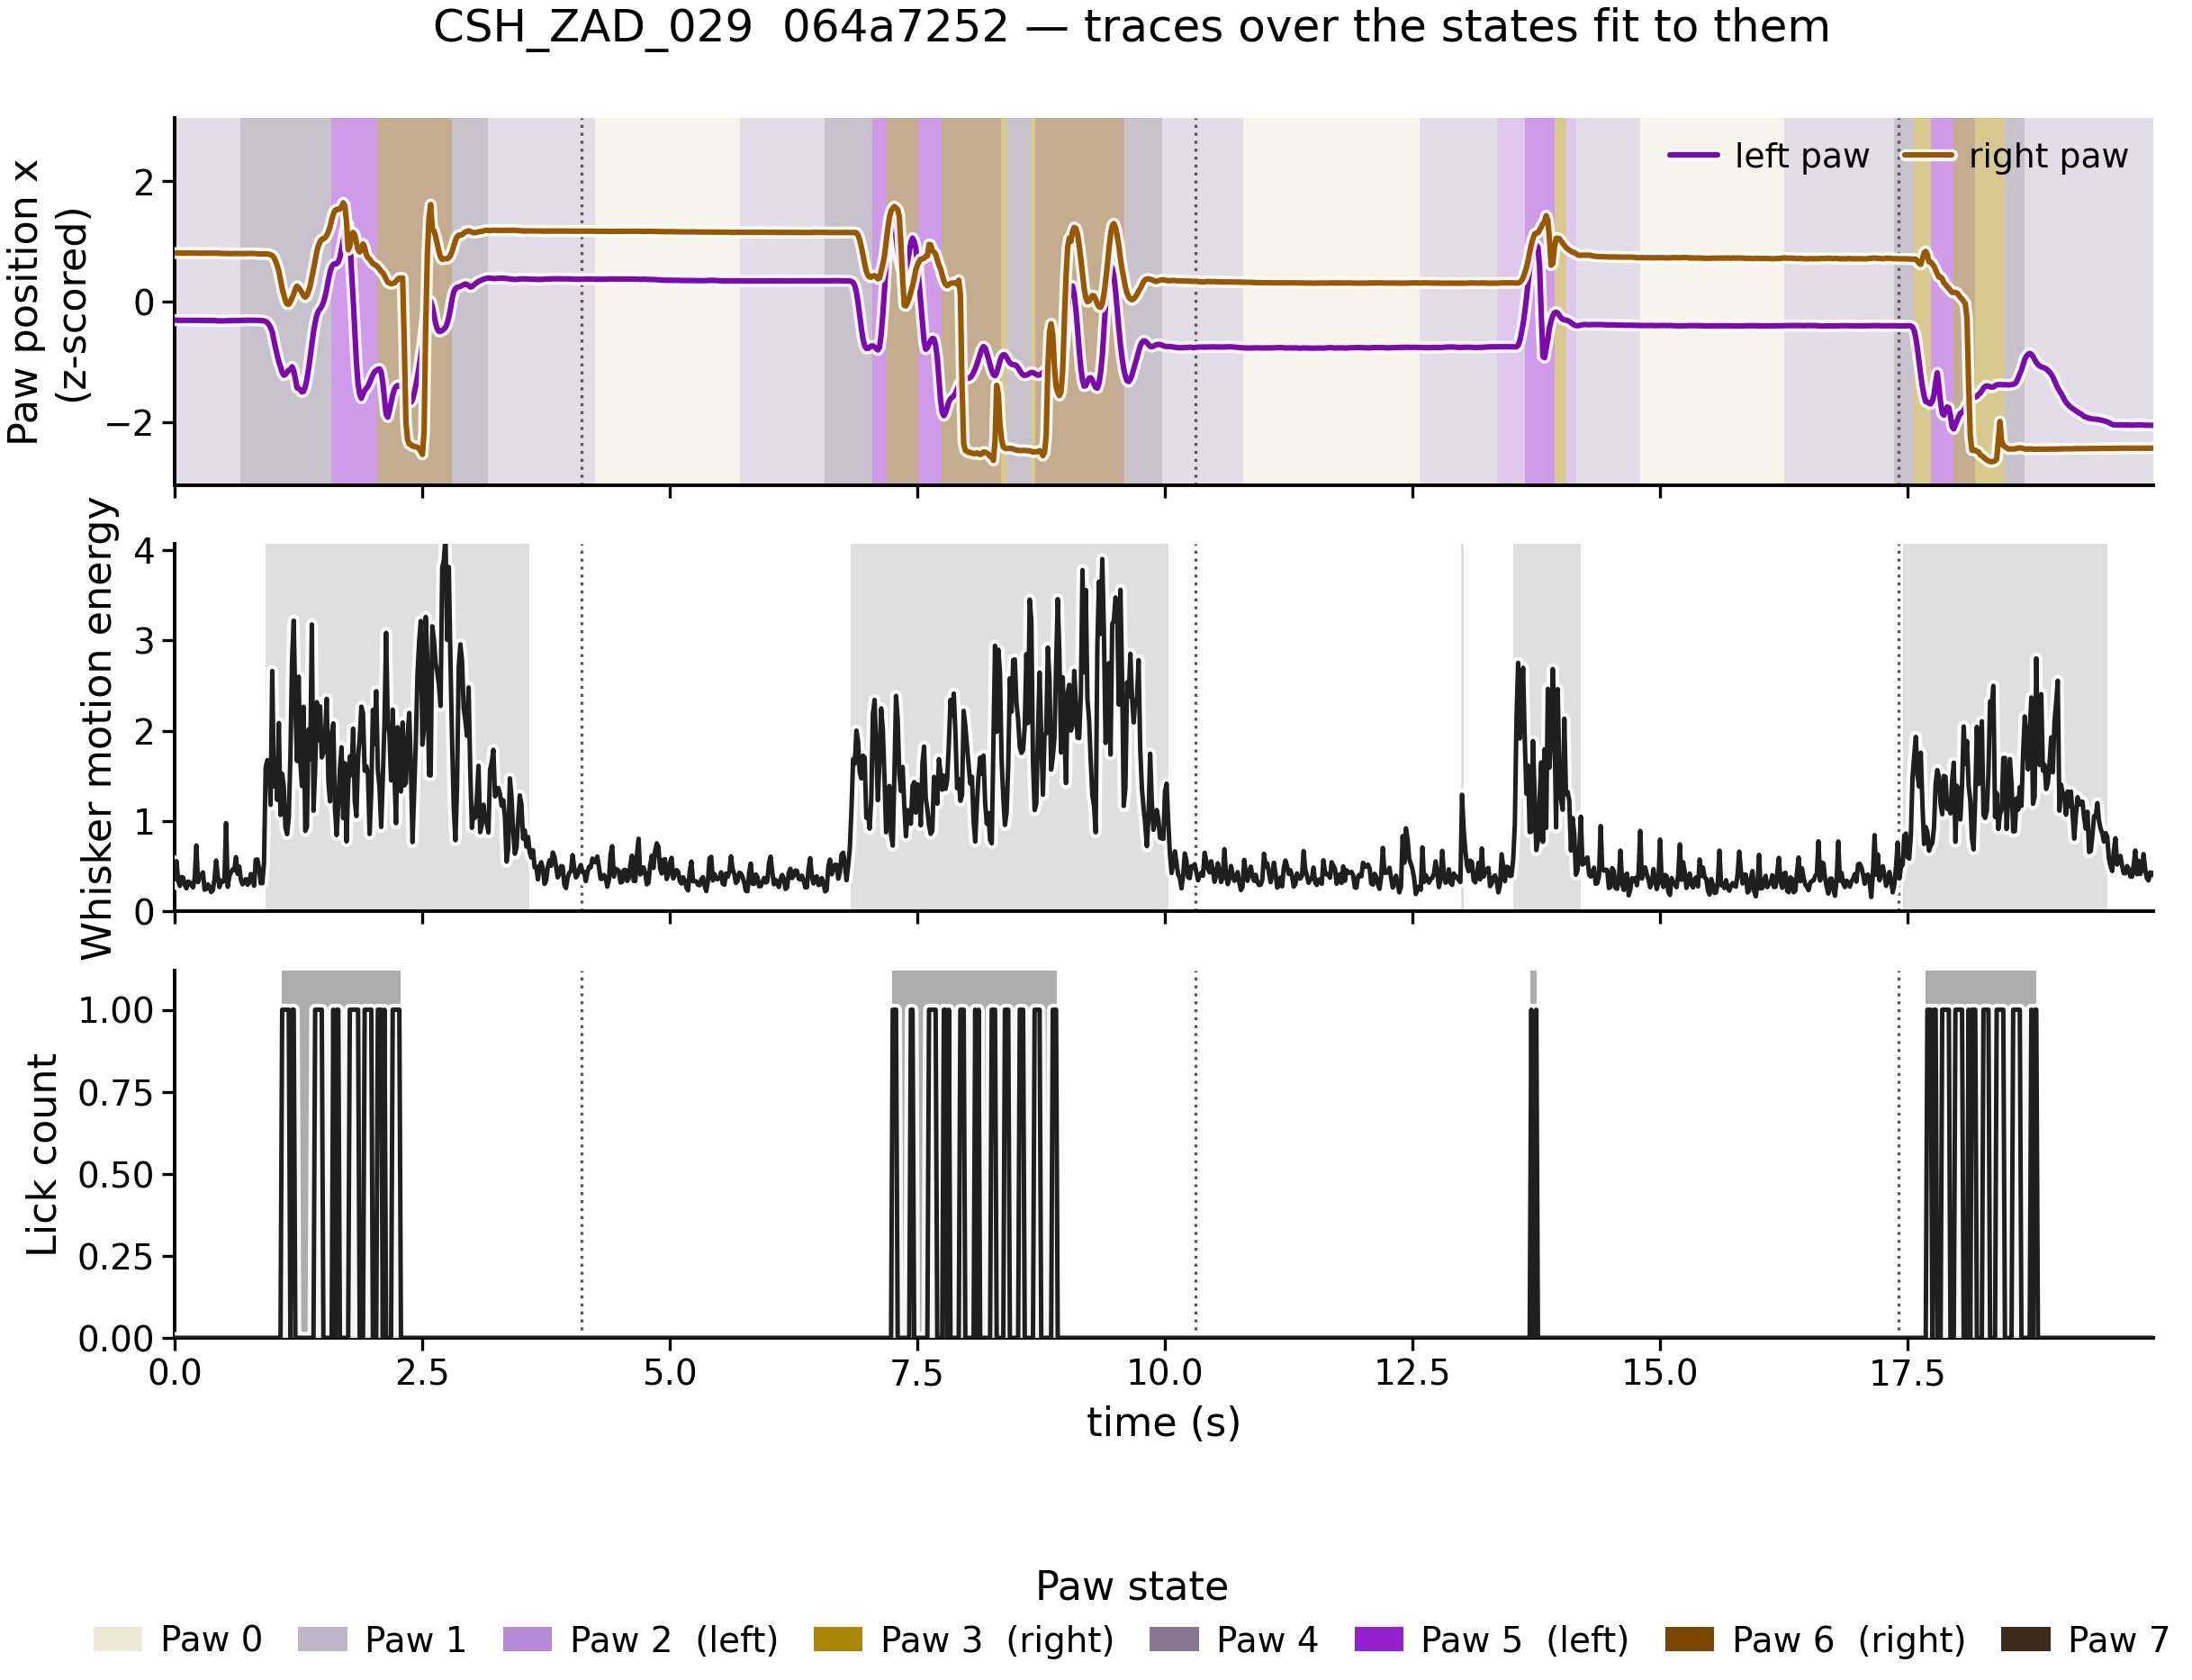

In [ ]:
"""A WINDOW OF ALL THREE CHANNELS, EACH TRACE OVER ITS OWN STATE SEQUENCE."""
from matplotlib.colors import ListedColormap
import matplotlib.patheffects as pe

TRISTRIP_SESSION = None       # None = the same session as the snippet above
TRISTRIP_SECONDS = 20.0
TRISTRIP_START   = 252       # seconds; None = pick the window by state diversity
PAW_TRACE        = 'position' # 'position' (z-scored, legible) | 'speed' (what the states see)
STATE_ALPHA      = 0.45       # how loud the background bands are
SHOW_GO_CUES     = True

# the binary state colours, reused by the donut below so bands and rings agree
WHISK_COLORS = ['white', '#B8B8B8']
LICK_COLORS = ['white', '#484949']

_ts = TRISTRIP_SESSION or _sess
_tm = seq.loc[seq['session'] == _ts, 'mouse_name'].iloc[0]
_f = STATES_FILES_DIR + f'8_states_file_{_ts}_{_tm}'
assert os.path.exists(_f), f'no states file for {_tm} {_ts}'

_d = pd.read_parquet(_f, columns=['Bin', 'Lick count', 'whisker_me', 'l_paw_x', 'l_paw_y',
                                  'r_paw_x', 'r_paw_y', 'most_likely_states',
                                  'goCueTrigger_times'])
_bins = _d['Bin'].to_numpy(float)


def _zs(v):
    """z-score over the WHOLE session, so the window keeps its place in the distribution."""
    return (v - np.nanmean(v)) / np.nanstd(v)


if PAW_TRACE == 'position':
    # the left camera's /2 is omitted on purpose: a z-score is scale-invariant, so it
    # would change nothing here. It is applied in the 'speed' branch, where it does matter.
    _lt, _rt = _zs(_d['l_paw_x'].to_numpy(float)), _zs(_d['r_paw_x'].to_numpy(float))
    _paw_ylab = 'Paw position x\n(z-scored)'
elif PAW_TRACE == 'speed':
    _lt = np.r_[np.nan, np.hypot(np.diff(_d['l_paw_x'].to_numpy(float) / 2),   # left cam /2
                                 np.diff(_d['l_paw_y'].to_numpy(float) / 2)) * FS]
    _rt = np.r_[np.nan, np.hypot(np.diff(_d['r_paw_x'].to_numpy(float)),
                                 np.diff(_d['r_paw_y'].to_numpy(float))) * FS]
    _paw_ylab = 'Paw speed (px/s)'
else:
    raise ValueError(f"PAW_TRACE must be 'position' or 'speed', got {PAW_TRACE!r}")

_paw, _wh, _li = ps.decode_syllables(ps.paw_codes(_d['most_likely_states'].to_numpy(float)),
                                     ps.N_PAW_STATES)
_w = int(TRISTRIP_SECONDS * FS)


def _diversity(i):
    """Entropy of the paw states in [i, i+_w), -inf unless all three channels vary."""
    p, wv, lv = _paw[i:i + _w], _wh[i:i + _w], _li[i:i + _w]
    ok = np.isfinite(p)
    if ok.mean() < 0.99:
        return -np.inf
    c = np.bincount(p[ok].astype(int), minlength=ps.N_PAW_STATES) / ok.sum()
    if not (0.05 < np.nanmean(wv) < 0.95) or not (0.02 < np.nanmean(lv) < 0.98):
        return -np.inf
    return float(-np.sum(np.where(c > 0, c * np.log(c), 0.0)))


if TRISTRIP_START is not None:
    _s0 = int(np.searchsorted(_bins, _bins[0] + TRISTRIP_START))
else:
    _best = max((_diversity(i), i) for i in range(0, len(_d) - _w, _w // 2))
    # the fallback matters: a session where licking never stops has no qualifying window
    _s0 = _best[1] if np.isfinite(_best[0]) else int(
        np.nanargmax([np.nanstd(_lt[i:i + _w]) for i in range(0, len(_d) - _w, _w)])) * _w
_sl = slice(_s0, _s0 + _w)
_t = _bins[_sl] - _bins[_s0]

_CH = [(_paw_ylab, None, ListedColormap(ps.PAW_STATE_COLORS), _paw[_sl],
        -0.5, ps.N_PAW_STATES - 0.5),
       ('Whisker motion energy', _d['whisker_me'].to_numpy(float)[_sl],
        ListedColormap(WHISK_COLORS), _wh[_sl], -0.5, 1.5),
       ('Lick count', _d['Lick count'].to_numpy(float)[_sl],
        ListedColormap(LICK_COLORS), _li[_sl], -0.5, 1.5)]
_halo = [pe.Stroke(linewidth=2.4, foreground='white', alpha=0.9), pe.Normal()]


def _limits(v, symmetric=False):
    """Robust y limits -- a few frames of tracking spike would otherwise set the scale."""
    f = np.asarray(v, float)
    f = f[np.isfinite(f)]
    if not len(f):
        return 0.0, 1.0
    lo, hi = np.nanpercentile(f, [0.5, 99.5])
    pad = 0.12 * (hi - lo if hi > lo else 1.0)
    if symmetric:
        m = max(abs(lo), abs(hi)) + pad
        return -m, m
    return float(min(0, lo) - pad * (lo < 0)), float(hi + pad)


fig, _axes = plt.subplots(3, 1, sharex=True, figsize=(ps.FIG['double'][0] * 1, 4.4),
                          gridspec_kw=dict(hspace=0.16))
for ax, (ylab, trace, cmap, states, vmin, vmax) in zip(_axes, _CH):
    if trace is None:
        lo, hi = _limits(np.r_[_lt[_sl], _rt[_sl]], symmetric=(PAW_TRACE == 'position'))
    else:
        lo, hi = _limits(trace)

    # THE STATE IS THE BACKGROUND -- full panel height, faded, trace drawn over it. The
    # extent is set from the limits computed above, so the band always fills the panel.
    ax.imshow(np.ma.masked_invalid(states)[None, :], aspect='auto', cmap=cmap,
              vmin=vmin, vmax=vmax, interpolation='nearest',
              extent=[_t[0], _t[-1], lo, hi], alpha=STATE_ALPHA, zorder=0)
    if SHOW_GO_CUES:
        for g in np.unique(_d['goCueTrigger_times'].to_numpy(float)[_sl]):
            if np.isfinite(g) and _bins[_s0] <= g <= _bins[_s0 + _w]:
                ax.axvline(g - _bins[_s0], color='0.35', lw=0.6, ls=':', zorder=1)
    if trace is None:
        ax.plot(_t, _lt[_sl], color=ps.PAW_LEFT, lw=1.1, zorder=3, label='left paw',
                path_effects=_halo)
        ax.plot(_t, _rt[_sl], color=ps.PAW_RIGHT, lw=1.1, zorder=3, label='right paw',
                path_effects=_halo)
        ax.legend(frameon=False, ncol=2, loc='upper right',
                  fontsize=plt.rcParams['font.size'] * 0.85)
    else:
        ax.plot(_t, trace, color='0.12', lw=0.9, zorder=3, path_effects=_halo)
    ax.set_ylim(lo, hi)
    ax.set_ylabel(ylab)
    ax.spines[['top', 'right']].set_visible(False)

_axes[-1].set_xlabel('time (s)')
_axes[-1].set_xlim(_t[0], _t[-1])
fig.suptitle(f'{_tm}  {_ts[:8]} \u2014 traces over the states fit to them', y=0.95)
ps.paw_legend(fig, ncol=8, missing=False, bbox_to_anchor=(0.5, -0.02))
print(f'  {PAW_TRACE}; window {_bins[_s0]:.0f}\u2013{_bins[_s0 + _w]:.0f} s of '
      f'{_bins[-1] / 60:.0f} min; paw-state entropy {_diversity(_s0):.2f} nats')
ps.savefig(fig, 'syllable_channel_snippet', svg=True)
plt.show()


## Building the groups

`codes_for` returns raw `binned_sequence` codes — no renumbering. `ps.syllable_histogram`
unpacks them itself with `ps.decode_syllables`, which is what removed fig 2A's two
`identifiable_mapping` dictionaries.

In [ ]:
def codes_for(rows):
    """(trials, bins) of RAW syllable codes for any subset of the sequence table."""
    piv = (rows.pivot(index=['sample'], columns=['broader_label'],
                      values='binned_sequence').dropna())
    if not len(piv):
        return np.empty((0, 10 * len(EPOCHS)))
    return np.vstack(piv[EPOCHS].apply(lambda r: np.hstack(r), axis=1)).astype(float)


def trial_field(frame, field):
    """One field out of the compound `trial_type` string, e.g. 'correct 0.25 0.8 right'."""
    return frame['trial_type'].str.split(' ').str[TRIAL_FIELDS.index(field)]


def make_groups():
    """-> [(panel title, codes), ...] for whatever GROUP_BY asks for."""
    if GROUP_BY == 'session':
        picks = seq['session'].value_counts().index[:N_GROUPS]
        return [(f"{seq.loc[seq['session'] == s, 'mouse_name'].iloc[0]}\n{s[:8]}",
                 codes_for(seq[seq['session'] == s])) for s in picks]

    if GROUP_BY == 'mouse':
        picks = seq['mouse_name'].value_counts().index[:N_GROUPS]
        return [(m, codes_for(seq[seq['mouse_name'] == m])) for m in picks]

    if GROUP_BY == 'trial_type':
        lvl = trial_field(seq, TRIAL_FIELD)
        keep = [l for l in sorted(lvl.dropna().unique())
                if (lvl == l).sum() >= MIN_TRIALS * len(EPOCHS)]
        dropped = sorted(set(lvl.dropna().unique()) - set(keep))
        if dropped:
            print(f'  below MIN_TRIALS and dropped: {dropped}')
        if TRIAL_FIELD == 'side':
            print("  NOTE 'side' comes from the choice strings, which are MIRRORED here -- "
                  "the panel labelled 'left' is the right side. Group on 'block' to orient.")
        return [(f'{TRIAL_FIELD} = {l}', codes_for(seq[lvl == l])) for l in keep]

    if GROUP_BY == 'ld_extremes':
        col = LD - 1
        have = emb[emb['session'].isin(seq['session'].unique())].sort_values(col)
        idx = np.linspace(0, len(have) - 1, N_GROUPS).round().astype(int)
        return [(f"LD{LD} = {have.iloc[i][col]:+.1f}\n{have.iloc[i]['mouse_name']}",
                 codes_for(seq[seq['session'] == have.iloc[i]['session']])) for i in idx]

    raise ValueError(f'GROUP_BY must be one of session|mouse|trial_type|ld_extremes, '
                     f'got {GROUP_BY!r}')

## Draw

One column per group. With `TEXTURE = True` (the default) that is a single panel carrying
all four channels — paw side and vigor in the colour, whisking and licking in the hatch —
and the panel is widened to whatever the hatch needs. With `TEXTURE = False` the whisk and
lick proportions go in a strip underneath instead.

Paw state 0 sits at the **top** of the stack, which is fig 2A's orientation (`imshow`'s
default `origin='upper'`) — `lowest_on_top=False` stacks upward instead.

  5 textured panels want a 23 in figure. A 40-bin panel needs ~4.6 in for the hatch to read, so texture suits 1-2 groups; lower N_GROUPS, or set TEXTURE = False for more.
  syllable_histogram: ~6 pt per bin, under the 12 a hatch needs -- widen the panel, show fewer bins, or use texture=False
  syllable_histogram: ~6 pt per bin, under the 12 a hatch needs -- widen the panel, show fewer bins, or use texture=False
  syllable_histogram: ~6 pt per bin, under the 12 a hatch needs -- widen the panel, show fewer bins, or use texture=False
  syllable_histogram: ~6 pt per bin, under the 12 a hatch needs -- widen the panel, show fewer bins, or use texture=False
  syllable_histogram: ~6 pt per bin, under the 12 a hatch needs -- widen the panel, show fewer bins, or use texture=False
not saved (ps.SAVE_FIGURES is False): figures/syllable_composition_session_02-10-2026.png, figures/syllable_composition_session_02-10-2026.svg   -- ps.saving(True) to write, or pass save=True


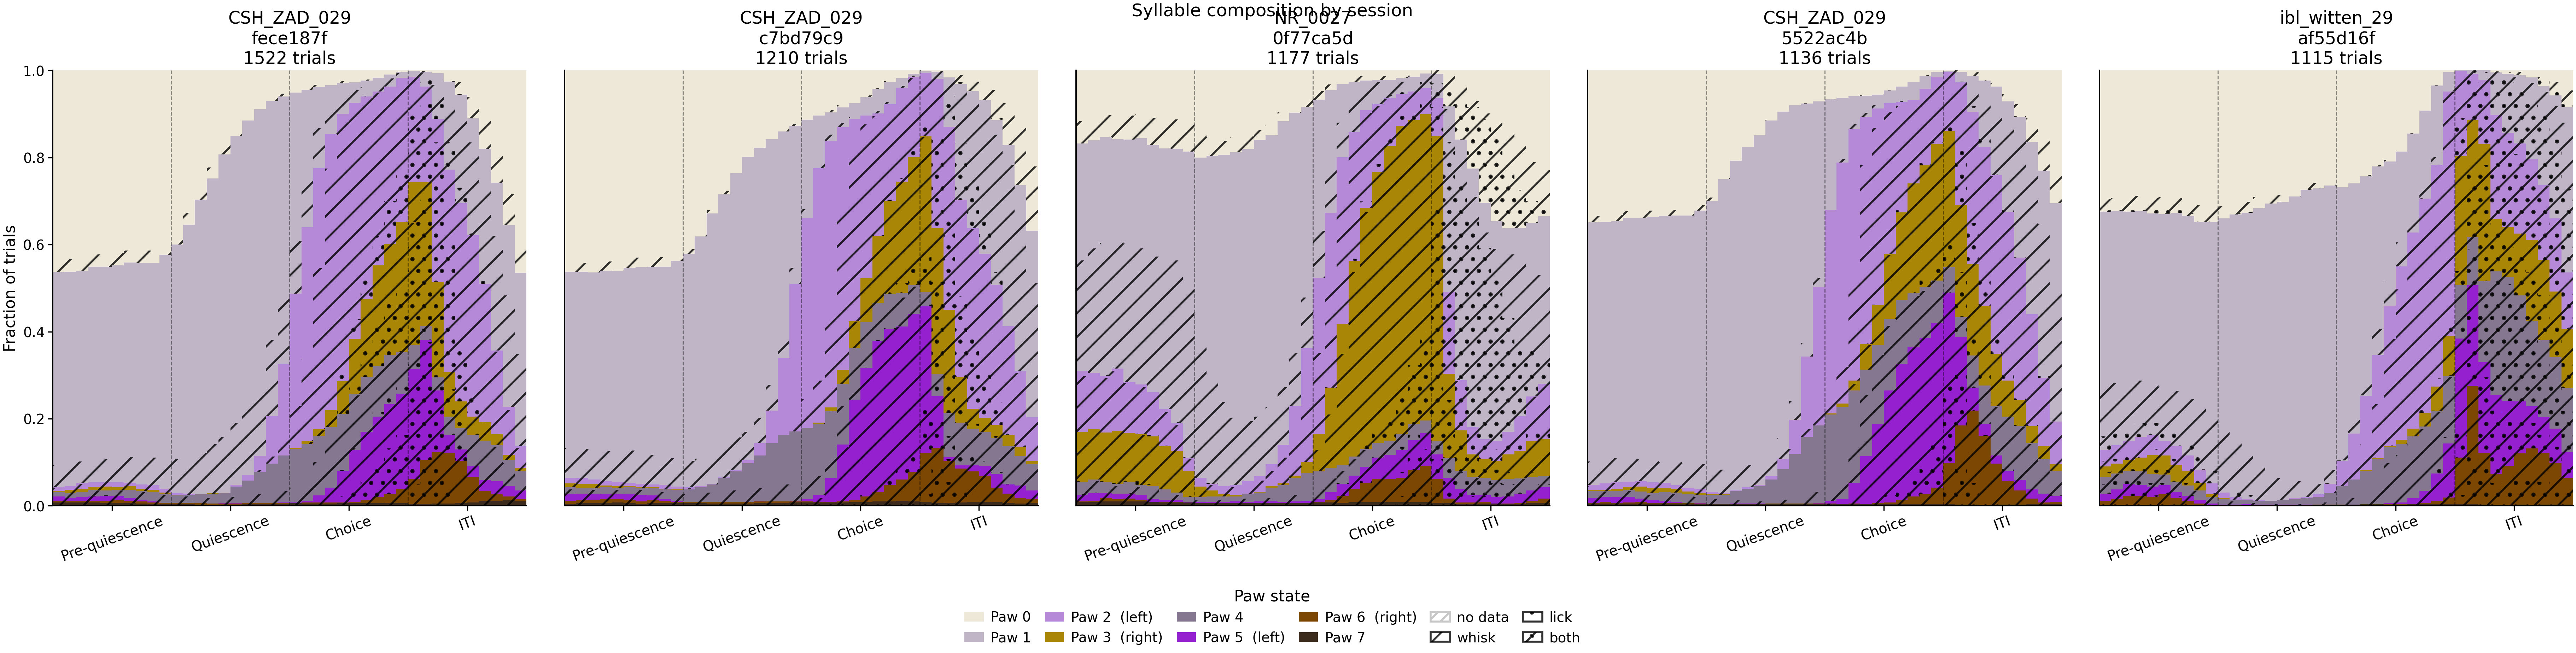

In [ ]:
groups = make_groups()
n_bins = groups[0][1].shape[1]

# WIDTH IS SET BY THE TEXTURE, not by taste. A hatch needs ps.HATCH_MIN_PT per bin of
# DRAWN AXES, and the axes are only about 75% of their grid slot once labels, the y axis and
# wspace are taken out -- sizing the slot to 12 pt per bin gives 9 pt of actual axes, which
# is under the threshold. So divide by that fraction rather than discovering it from the
# warning syllable_histogram prints.
AXES_FRAC = 0.75
panel_w = n_bins * ps.HATCH_MIN_PT / 72 / AXES_FRAC if TEXTURE else 4.6
panel_w = 4.6

if TEXTURE and panel_w * len(groups) > 22:
    print(f'  {len(groups)} textured panels want a {panel_w * len(groups):.0f} in figure. '
          f'A 40-bin panel needs ~{panel_w:.1f} in for the hatch to read, so texture suits '
          f'1-2 groups; lower N_GROUPS, or set TEXTURE = False for more.')

fig = plt.figure(figsize=(panel_w * len(groups), 4.0 if TEXTURE else 4.4))
gs = (fig.add_gridspec(1, len(groups), wspace=0.08) if TEXTURE else
      fig.add_gridspec(2, len(groups), height_ratios=[3, 1], hspace=0.12, wspace=0.08))

for k, (name, codes) in enumerate(groups):
    ax = fig.add_subplot(gs[0, k] if not TEXTURE else gs[0, k])
    ps.syllable_histogram(codes, ax=ax, texture=TEXTURE)
    ps.epoch_lines(ax, codes.shape[1])
    ax.set_title(f'{name}\n{len(codes)} trials', fontsize=plt.rcParams['font.size'] * 1.1)

    if TEXTURE:
        # the texture already carries whisk and lick, so the strip would be redundant
        ax.set_xticks([5, 15, 25, 35])
        ax.set_xticklabels(EPOCHS, fontsize=plt.rcParams['font.size'] * 0.9, rotation=20)
        if k:
            ax.set_yticks([]); ax.set_ylabel('')
    else:
        ax.set_xticks([])
        axb = fig.add_subplot(gs[1, k])
        ps.whisk_lick_panel(codes, ax=axb)
        ps.epoch_lines(axb, codes.shape[1])
        axb.set_xticks([5, 15, 25, 35])
        axb.set_xticklabels(EPOCHS, fontsize=plt.rcParams['font.size'] * 0.9, rotation=20)
        if k:
            ax.set_yticks([]); ax.set_ylabel('')
            axb.set_yticks([]); axb.set_ylabel('')
        if k == len(groups) - 1:
            axb.legend(fontsize=plt.rcParams['font.size'] * 0.9, loc='upper left',
                       frameon=False)

ps.paw_legend(fig, ncol=6 if TEXTURE else 9, hatch=TEXTURE, bbox_to_anchor=(0.5, -0.02))
_sub = f' ({TRIAL_FIELD})' if GROUP_BY == 'trial_type' else ''
fig.suptitle(f'Syllable composition by {GROUP_BY}{_sub}', y=1.0)

ps.savefig(fig, f'syllable_composition_{GROUP_BY}', svg=True)   # ps.saving(True) to write
plt.show()

## Mean syllable occupancy across all sessions

The panels above compare groups. This asks what the **average** composition is, and how much
sessions vary around it.

**The unit is the session, not the trial.** Sessions run a few hundred to ~900 trials, so
pooling trials would let the longest sessions set the mean. Every session contributes one
occupancy vector and those are averaged, so the number reads as *what the average session
looks like* and the spread is genuine between-session variability rather than sampling noise.

Occupancy is over non-missing bins only. A missing bin is a tracking dropout, and
`ps.decode_syllables` keeps it NaN in all three channels rather than letting it decode to paw
state 0 — which is a real and very common state, so the mistake would be invisible.


In [ ]:
"""PER-SESSION OCCUPANCY OF EVERY CHANNEL -- decoded once, for the whole table."""
N_STATES = len(ps.PAW_STATE_COLORS)
STATE_COLS = [f'paw{i}' for i in range(N_STATES)]

# Decode the WHOLE sequence table in one shot rather than pivoting per session: `seq` is one
# row per (trial, epoch) holding a 10-bin array, so stacking gives every bin at once.
_arr = np.vstack(seq['binned_sequence'].to_numpy())
_paw, _whisk, _lick = ps.decode_syllables(_arr, N_STATES)
_session = seq['session'].to_numpy()
_epoch = seq['broader_label'].to_numpy()


def occupancy_by(keys, mask=None):
    """-> DataFrame (group x [paw0..paw7, whisk, lick]) of fractions of non-missing bins."""
    p, w, l = (_paw, _whisk, _lick) if mask is None else (_paw[mask], _whisk[mask], _lick[mask])
    k = np.asarray(keys) if mask is None else np.asarray(keys)[mask]
    rows, names = [], []
    for kv in pd.unique(k):
        m = (k == kv)
        pv, wv, lv = p[m].ravel(), w[m].ravel(), l[m].ravel()
        ok = ~np.isnan(pv)
        if not ok.sum():
            continue
        rows.append(np.r_[np.bincount(pv[ok].astype(int), minlength=N_STATES) / ok.sum(),
                          np.nanmean(wv), np.nanmean(lv)])
        names.append(kv)
    return pd.DataFrame(rows, index=names, columns=STATE_COLS + ['whisk', 'lick'])


OCC = occupancy_by(_session)                                     # session x channel
OCC_EPOCH = {ep: occupancy_by(_session, _epoch == ep) for ep in EPOCHS}
OCC_EPOCH_MEAN = pd.DataFrame({ep: v.mean() for ep, v in OCC_EPOCH.items()}).T

_ord_cols = [f'paw{s}' for s in ps.PAW_VIGOR_ORDER] + ['whisk', 'lick']
print(f'{len(OCC)} sessions, {seq["mouse_name"].nunique()} mice\n')
print('occupancy across sessions (vigor order, then whisk and lick):')
print(pd.DataFrame({'mean': OCC.mean(), 'sd': OCC.std(),
                    'min session': OCC.min(), 'max session': OCC.max()})
      .loc[_ord_cols].round(3).to_string())
print('\nmean occupancy by epoch:')
print(OCC_EPOCH_MEAN[_ord_cols].round(3).to_string())


332 sessions, 101 mice

occupancy across sessions (vigor order, then whisk and lick):
        mean     sd  min session  max session
paw0   0.151  0.062        0.037        0.444
paw1   0.406  0.049        0.209        0.594
paw2   0.131  0.053        0.020        0.362
paw3   0.087  0.040        0.003        0.247
paw4   0.115  0.053        0.016        0.360
paw5   0.066  0.024        0.011        0.127
paw6   0.039  0.024        0.003        0.159
paw7   0.006  0.004        0.000        0.023
whisk  0.583  0.124        0.019        0.928
lick   0.195  0.085        0.022        0.535

mean occupancy by epoch:
                 paw0   paw1   paw2   paw3   paw4   paw5   paw6   paw7  whisk   lick
Pre-quiescence  0.221  0.517  0.087  0.050  0.068  0.033  0.019  0.006  0.500  0.080
Quiescence      0.171  0.631  0.054  0.009  0.124  0.003  0.003  0.005  0.284  0.041
Choice          0.102  0.152  0.224  0.177  0.136  0.133  0.070  0.006  0.699  0.174
ITI             0.112  0.318  0.158  0.115

not saved (ps.SAVE_FIGURES is False): figures/syllable_occupancy_all_sessions_02-10-2026.png, figures/syllable_occupancy_all_sessions_02-10-2026.svg   -- ps.saving(True) to write, or pass save=True


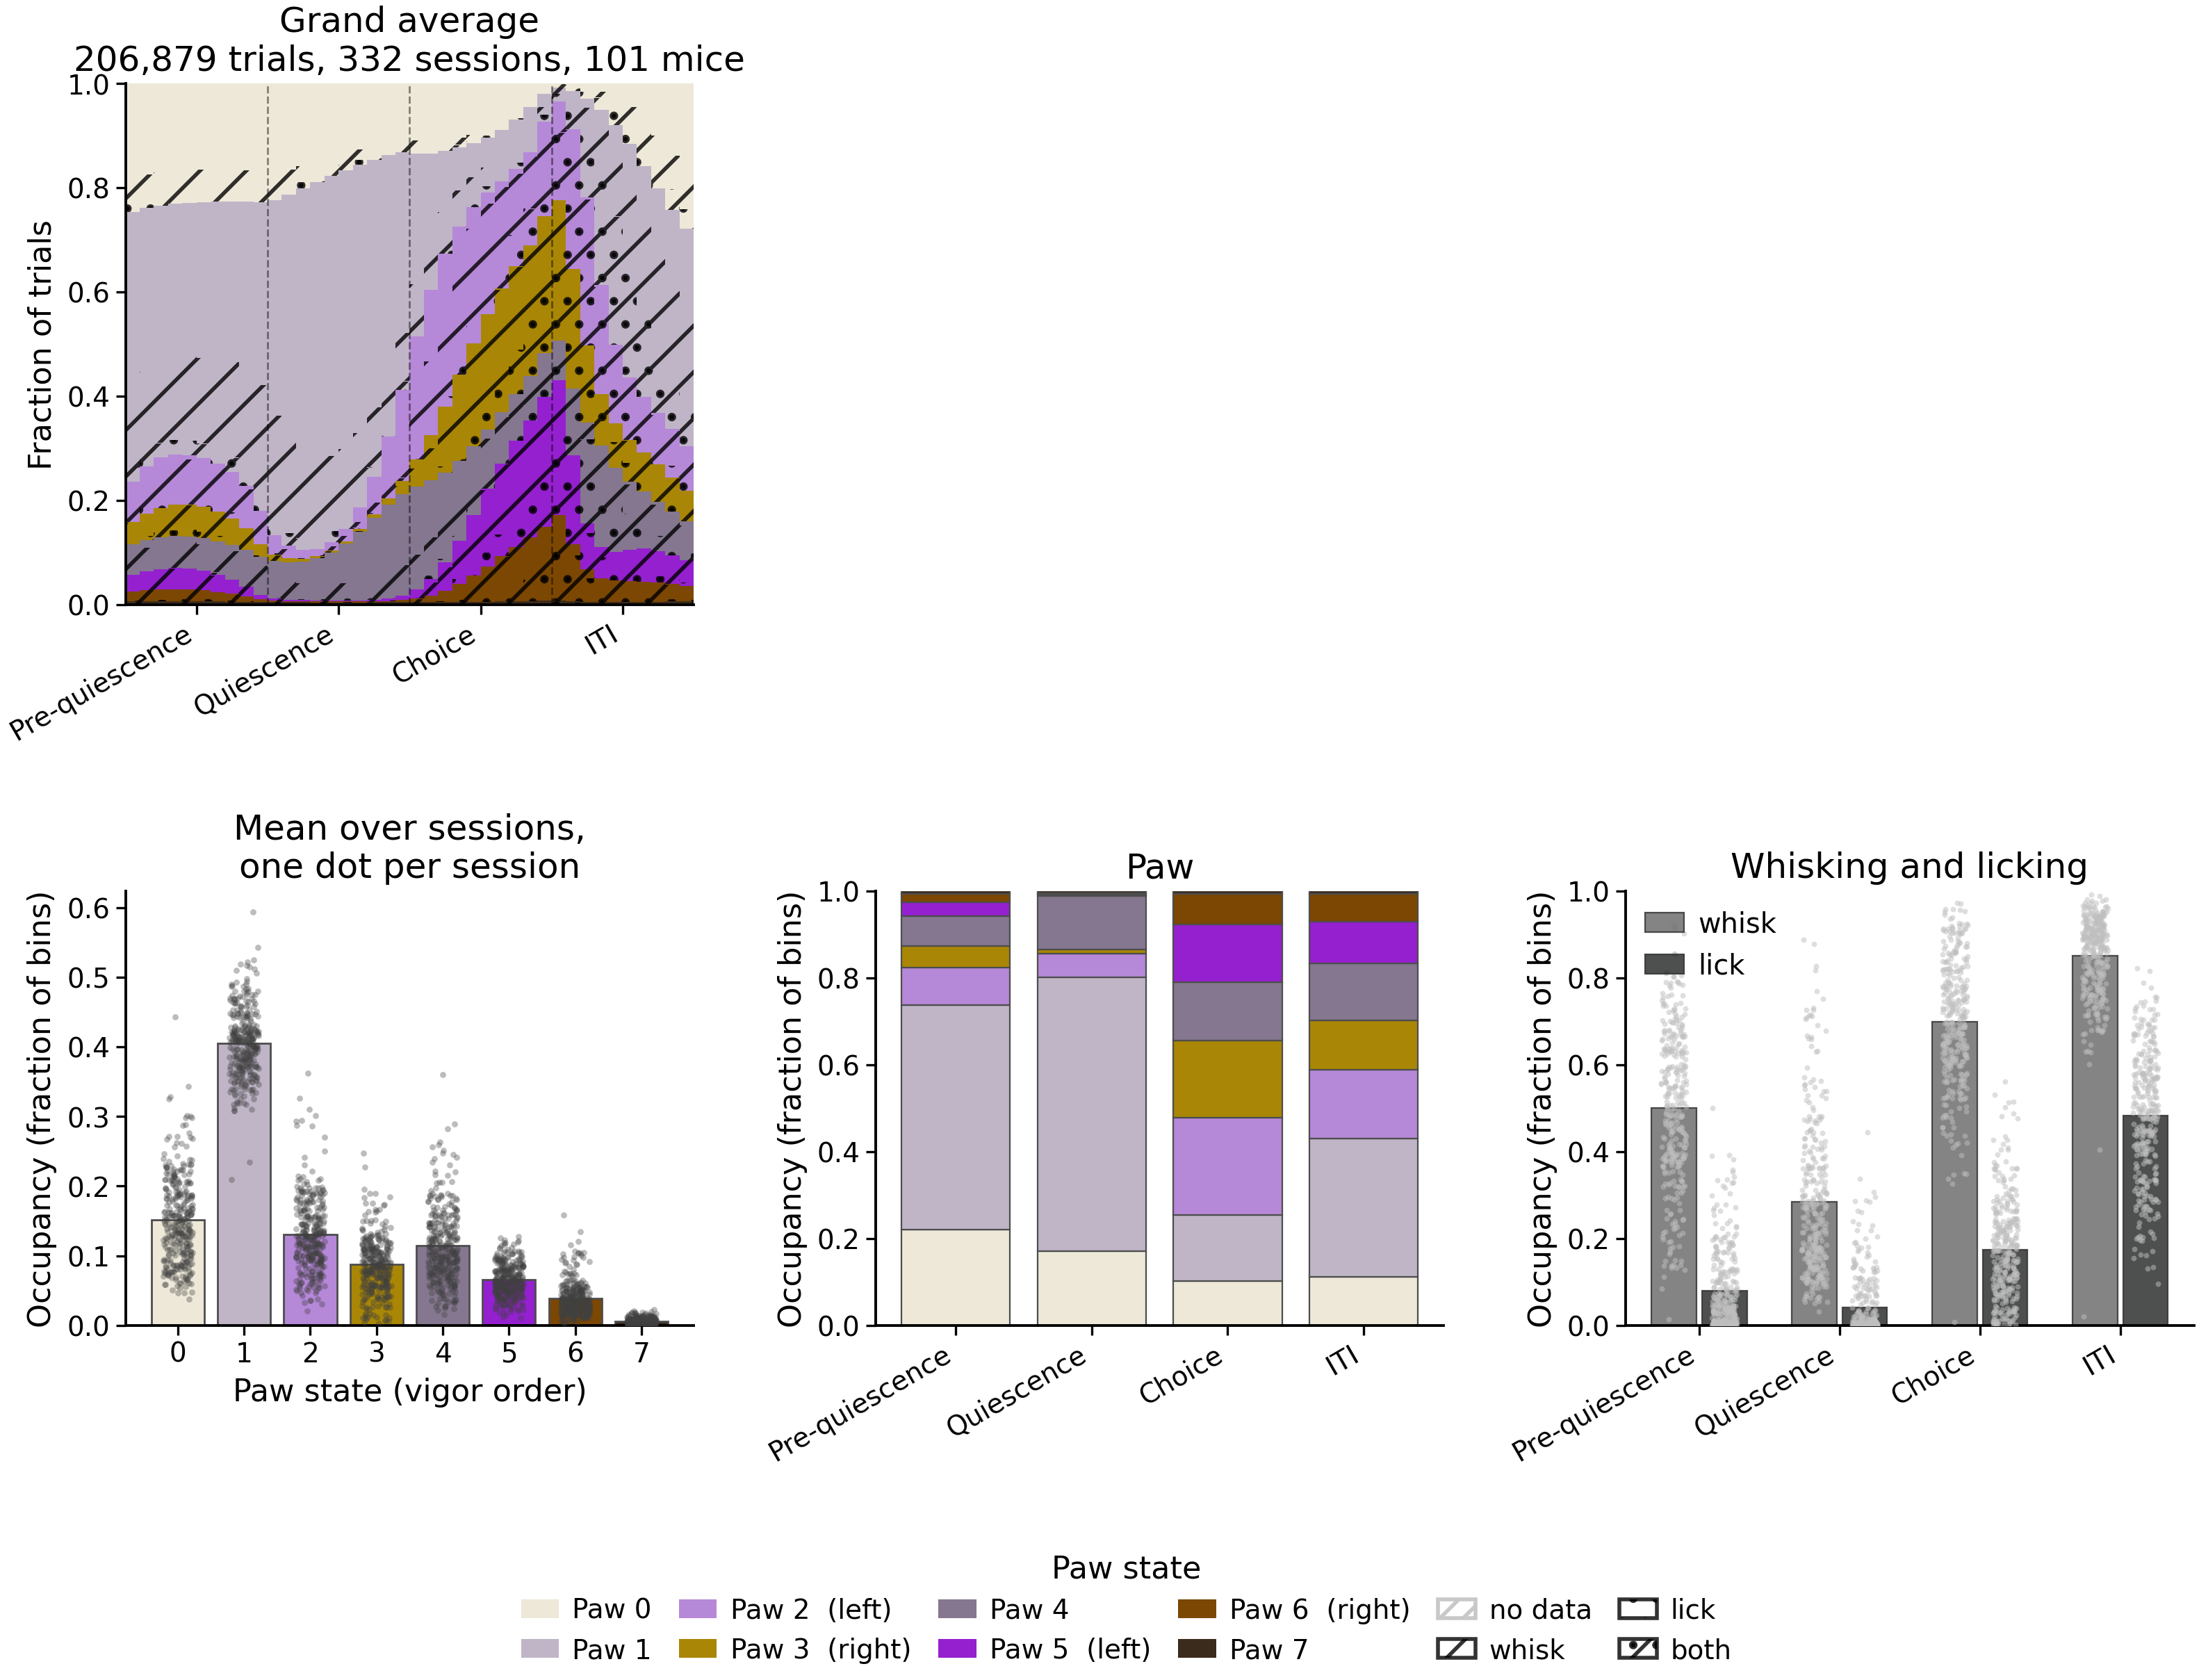

In [ ]:
"""FIGURE -- the average session, and the spread around it."""
ORD = ps.PAW_VIGOR_ORDER            # pale-to-dark, so the stack reads as a vigor ramp
_rng = np.random.default_rng(0)

fig = plt.figure(figsize=(9.6, 5.8))
gs = fig.add_gridspec(2, 3, height_ratios=[1.2, 1], hspace=0.6, wspace=0.32)

# (a) grand-average composition over the trial -- every trial in the dataset
ax0 = fig.add_subplot(gs[0, 0])    # one column wide, to line up with (b)
ALL_CODES = codes_for(seq)
# warn=False: only ~4 pt per bin here, under ps.HATCH_MIN_PT, but the hatch is drawn on one
# grid across neighbouring patches, so a block spanning several bins still reads
ps.syllable_histogram(ALL_CODES, ax=ax0, texture=True, warn=False)
ps.epoch_lines(ax0, ALL_CODES.shape[1])
ax0.set_xticks([5, 15, 25, 35]); ax0.set_xticklabels(EPOCHS, rotation=30, ha='right')
ax0.set_title(f'Grand average\n{len(ALL_CODES):,} trials, {len(OCC)} sessions, '
              f'{seq["mouse_name"].nunique()} mice')

# (b) occupancy per state, one dot per session. The bar is the mean OVER SESSIONS, so a long
#     session does not outvote a short one; the dots are what the mean hides.
ax1 = fig.add_subplot(gs[1, 0])
for j, s in enumerate(ORD):
    v = OCC[f'paw{s}'].to_numpy()
    ax1.bar(j, v.mean(), color=ps.PAW_STATE_COLORS[s], edgecolor='0.3', linewidth=0.5)
    ax1.scatter(j + _rng.uniform(-0.22, 0.22, len(v)), v, s=2.5, color='0.25',
                alpha=0.35, linewidths=0, zorder=3)
ax1.set_xticks(range(len(ORD))); ax1.set_xticklabels([str(s) for s in ORD])
ax1.set_xlabel('Paw state (vigor order)')
ax1.set_ylabel('Occupancy (fraction of bins)')
ax1.set_title('Mean over sessions,\none dot per session')

# (c) the same split by epoch, stacked -- each bar sums to 1 by construction
ax2 = fig.add_subplot(gs[1, 1])
bottom = np.zeros(len(EPOCHS))
for s in ORD:
    v = OCC_EPOCH_MEAN[f'paw{s}'].to_numpy()
    ax2.bar(range(len(EPOCHS)), v, bottom=bottom, color=ps.PAW_STATE_COLORS[s],
            edgecolor='0.3', linewidth=0.4)
    bottom += v
ax2.set_xticks(range(len(EPOCHS)))
ax2.set_xticklabels(EPOCHS, rotation=30, ha='right')
ax2.set_ylim(0, 1); ax2.set_ylabel('Occupancy (fraction of bins)')
ax2.set_title('Paw')

# (d) whisk and lick are PROPORTIONS, not a partition, so they get their own panel
ax3 = fig.add_subplot(gs[1, 2])
for j, (ch, col) in enumerate([('whisk', '#6E6E6E'), ('lick', '#2F3030')]):
    for e, ep in enumerate(EPOCHS):
        v = OCC_EPOCH[ep][ch].to_numpy()
        x = e + (j - 0.5) * 0.36
        ax3.bar(x, np.nanmean(v), width=0.32, color=col, alpha=0.85, edgecolor='0.2',
                linewidth=0.4, label=ch if e == 0 else None)
        ax3.scatter(x + _rng.uniform(-0.09, 0.09, len(v)), v, s=2, color='0.75',
                    alpha=0.5, linewidths=0, zorder=3)
ax3.set_xticks(range(len(EPOCHS)))
ax3.set_xticklabels(EPOCHS, rotation=30, ha='right')
ax3.set_ylabel('Occupancy (fraction of bins)'); ax3.set_ylim(0, 1)
ax3.set_title('Whisking and licking')
ax3.legend(frameon=False, fontsize=plt.rcParams['font.size'] * 0.9)

ps.paw_legend(fig, ncol=6, hatch=True, bbox_to_anchor=(0.5, -0.02))
ps.savefig(fig, 'syllable_occupancy_all_sessions', svg=True)
plt.show()


In [ ]:
"""PICKING EXAMPLE SESSIONS -- shared by the donuts and the real-time stacks.

`make_groups()` with GROUP_BY='session' takes the longest sessions, which in this dataset
means one prolific mouse can fill several panels. For EXAMPLES that is the wrong choice
twice over: panels should show different animals, and the session with the most trials is
often also the one with the worst paw tracking (CSH_ZAD_026 is both).
"""
N_EXAMPLES    = 4        # panels of example sessions
ONE_PER_MOUSE = True     # a different animal in every panel
MAX_MISSING   = 0.05     # skip sessions with more than this fraction of missing bins

_missing_by_session = (pd.Series(np.isnan(_arr).mean(axis=1), index=_session)
                       .groupby(level=0).mean())


def example_sessions(n=None, one_per_mouse=None, max_missing=None):
    """-> [(session, mouse, n_trials, missing_fraction), ...], longest first."""
    n = N_EXAMPLES if n is None else n
    one_per_mouse = ONE_PER_MOUSE if one_per_mouse is None else one_per_mouse
    max_missing = MAX_MISSING if max_missing is None else max_missing
    tbl = (seq.groupby(['session', 'mouse_name']).size().div(len(EPOCHS))
           .reset_index(name='n_trials')
           .assign(missing=lambda d: d['session'].map(_missing_by_session))
           .query('missing <= @max_missing')
           .sort_values('n_trials', ascending=False))
    if one_per_mouse:
        tbl = tbl.drop_duplicates('mouse_name')
    return list(tbl.head(n).itertuples(index=False, name=None))


EXAMPLES = example_sessions()
for s, m, n, miss in EXAMPLES:
    print(f'  {m:16s} {s[:8]}  {int(n):5d} trials  {miss:.1%} missing bins')


  CSH_ZAD_029      fece187f   1523 trials  0.0% missing bins
  NR_0027          0f77ca5d   1186 trials  0.0% missing bins
  ibl_witten_29    af55d16f   1116 trials  0.0% missing bins
  ibl_witten_26    dc21e80d   1101 trials  0.0% missing bins


## Conditional-probability donut

Ported from `1_segmentation/1_b.ipynb` (`plot_single_polar_3`), redrawn in `ps.PAW_STATE_COLORS`
so it matches every other panel here. Three nested rings, each conditioned on the one inside it:

| ring | quantity |
|---|---|
| inner | P(paw state) |
| middle | P(whisk \| paw) — light grey = whisking |
| outer | P(lick \| paw, whisk) — dark grey = licking |

Every wedge's angle is the *joint* probability, so the outer ring still sums to one full turn
and a wedge's width reads directly as "how much of the session is this combination".

**Probabilities are computed within trial, then averaged across trials**, matching the original —
so each trial counts once regardless of length, the same choice as the occupancy section above,
one level down. A trial in which a paw state never occurs simply does not contribute to that
state's conditional, rather than contributing a zero.

The original also drew two blank white rings outside these three. They carry no data, so they
are dropped; `radii` takes a longer list if you want them back for annotation.


In [ ]:
"""NESTED CONDITIONAL PROBABILITIES -> a donut, for any set of trials."""
# the same pair the state strips use, so the rings and the snippet agree
WHISK_RING_COLORS, LICK_RING_COLORS = WHISK_COLORS, LICK_COLORS


def conditional_probs(codes, n_paw_states=N_STATES):
    """-> P(paw)[s], P(whisk|paw)[s, w], P(lick|paw, whisk)[s, w, l]."""
    paw, whisk, lick = ps.decode_syllables(np.asarray(codes, float), n_paw_states)
    n_tr = paw.shape[0]
    frac = np.full((n_tr, n_paw_states), np.nan)
    wfrac = np.full((n_tr, n_paw_states, 2), np.nan)
    lfrac = np.full((n_tr, n_paw_states, 2, 2), np.nan)
    for t in range(n_tr):
        ok = ~np.isnan(paw[t])
        if not ok.sum():
            continue
        pv, wv, lv = (paw[t][ok].astype(int), whisk[t][ok].astype(int),
                      lick[t][ok].astype(int))
        frac[t] = np.bincount(pv, minlength=n_paw_states) / len(pv)
        for s in np.unique(pv):
            ms = pv == s
            for wvl in (0, 1):
                mw = ms & (wv == wvl)
                wfrac[t, s, wvl] = mw.sum() / ms.sum()
                if mw.sum():
                    for lvl in (0, 1):
                        lfrac[t, s, wvl, lvl] = (mw & (lv == lvl)).sum() / mw.sum()
    with np.errstate(invalid='ignore'):
        P_paw = np.nanmean(frac, axis=0)
        P_paw = P_paw / np.nansum(P_paw)          # renormalise, for polar safety
        return P_paw, np.nanmean(wfrac, axis=0), np.nanmean(lfrac, axis=0)


def syllable_donut(codes, ax, title=None, n_paw_states=N_STATES, radii=None):
    """Three nested rings: paw, whisk|paw, lick|paw,whisk. `ax` must be polar."""
    P_paw, P_w, P_l = conditional_probs(codes, n_paw_states)
    radii = radii or [(0.30, 0.62), (0.62, 0.86), (0.86, 1.08)]
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_axis_off()

    def wedge(start, theta, ring, color):
        ax.bar(start + theta / 2, radii[ring][1] - radii[ring][0], width=theta,
               bottom=radii[ring][0], color=color, edgecolor='0.45', linewidth=0.3)

    start = 0.0
    for s in range(n_paw_states):
        th = 2 * np.pi * P_paw[s]
        if np.isfinite(th) and th > 0:
            wedge(start, th, 0, ps.PAW_STATE_COLORS[s]); start += th
    start = 0.0
    for s in range(n_paw_states):
        for wv in (0, 1):
            th = 2 * np.pi * P_paw[s] * P_w[s, wv]
            if np.isfinite(th) and th > 0:
                wedge(start, th, 1, WHISK_RING_COLORS[wv]); start += th
    start = 0.0
    for s in range(n_paw_states):
        for wv in (0, 1):
            for lv in (0, 1):
                th = 2 * np.pi * P_paw[s] * P_w[s, wv] * P_l[s, wv, lv]
                if np.isfinite(th) and th > 0:
                    wedge(start, th, 2, LICK_RING_COLORS[lv]); start += th

    tr = np.linspace(0, 2 * np.pi, 200)
    for r in [radii[0][0], radii[0][1], radii[1][1], radii[2][1]]:
        ax.plot(tr, [r] * len(tr), color='0.45', linewidth=0.8)
    ax.set_ylim(0, radii[2][1] * 1.02)
    if title:
        ax.set_title(title, va='bottom', fontsize=plt.rcParams['font.size'])
    return P_paw, P_w, P_l


/tmp/ipykernel_122750/2674299666.py:31: RuntimeWarning: Mean of empty slice
  return P_paw, np.nanmean(wfrac, axis=0), np.nanmean(lfrac, axis=0)
/tmp/ipykernel_122750/2674299666.py:31: RuntimeWarning: Mean of empty slice
  return P_paw, np.nanmean(wfrac, axis=0), np.nanmean(lfrac, axis=0)
/tmp/ipykernel_122750/2674299666.py:31: RuntimeWarning: Mean of empty slice
  return P_paw, np.nanmean(wfrac, axis=0), np.nanmean(lfrac, axis=0)
/tmp/ipykernel_122750/2674299666.py:31: RuntimeWarning: Mean of empty slice
  return P_paw, np.nanmean(wfrac, axis=0), np.nanmean(lfrac, axis=0)


not saved (ps.SAVE_FIGURES is False): figures/syllable_donut_02-10-2026.png, figures/syllable_donut_02-10-2026.svg   -- ps.saving(True) to write, or pass save=True


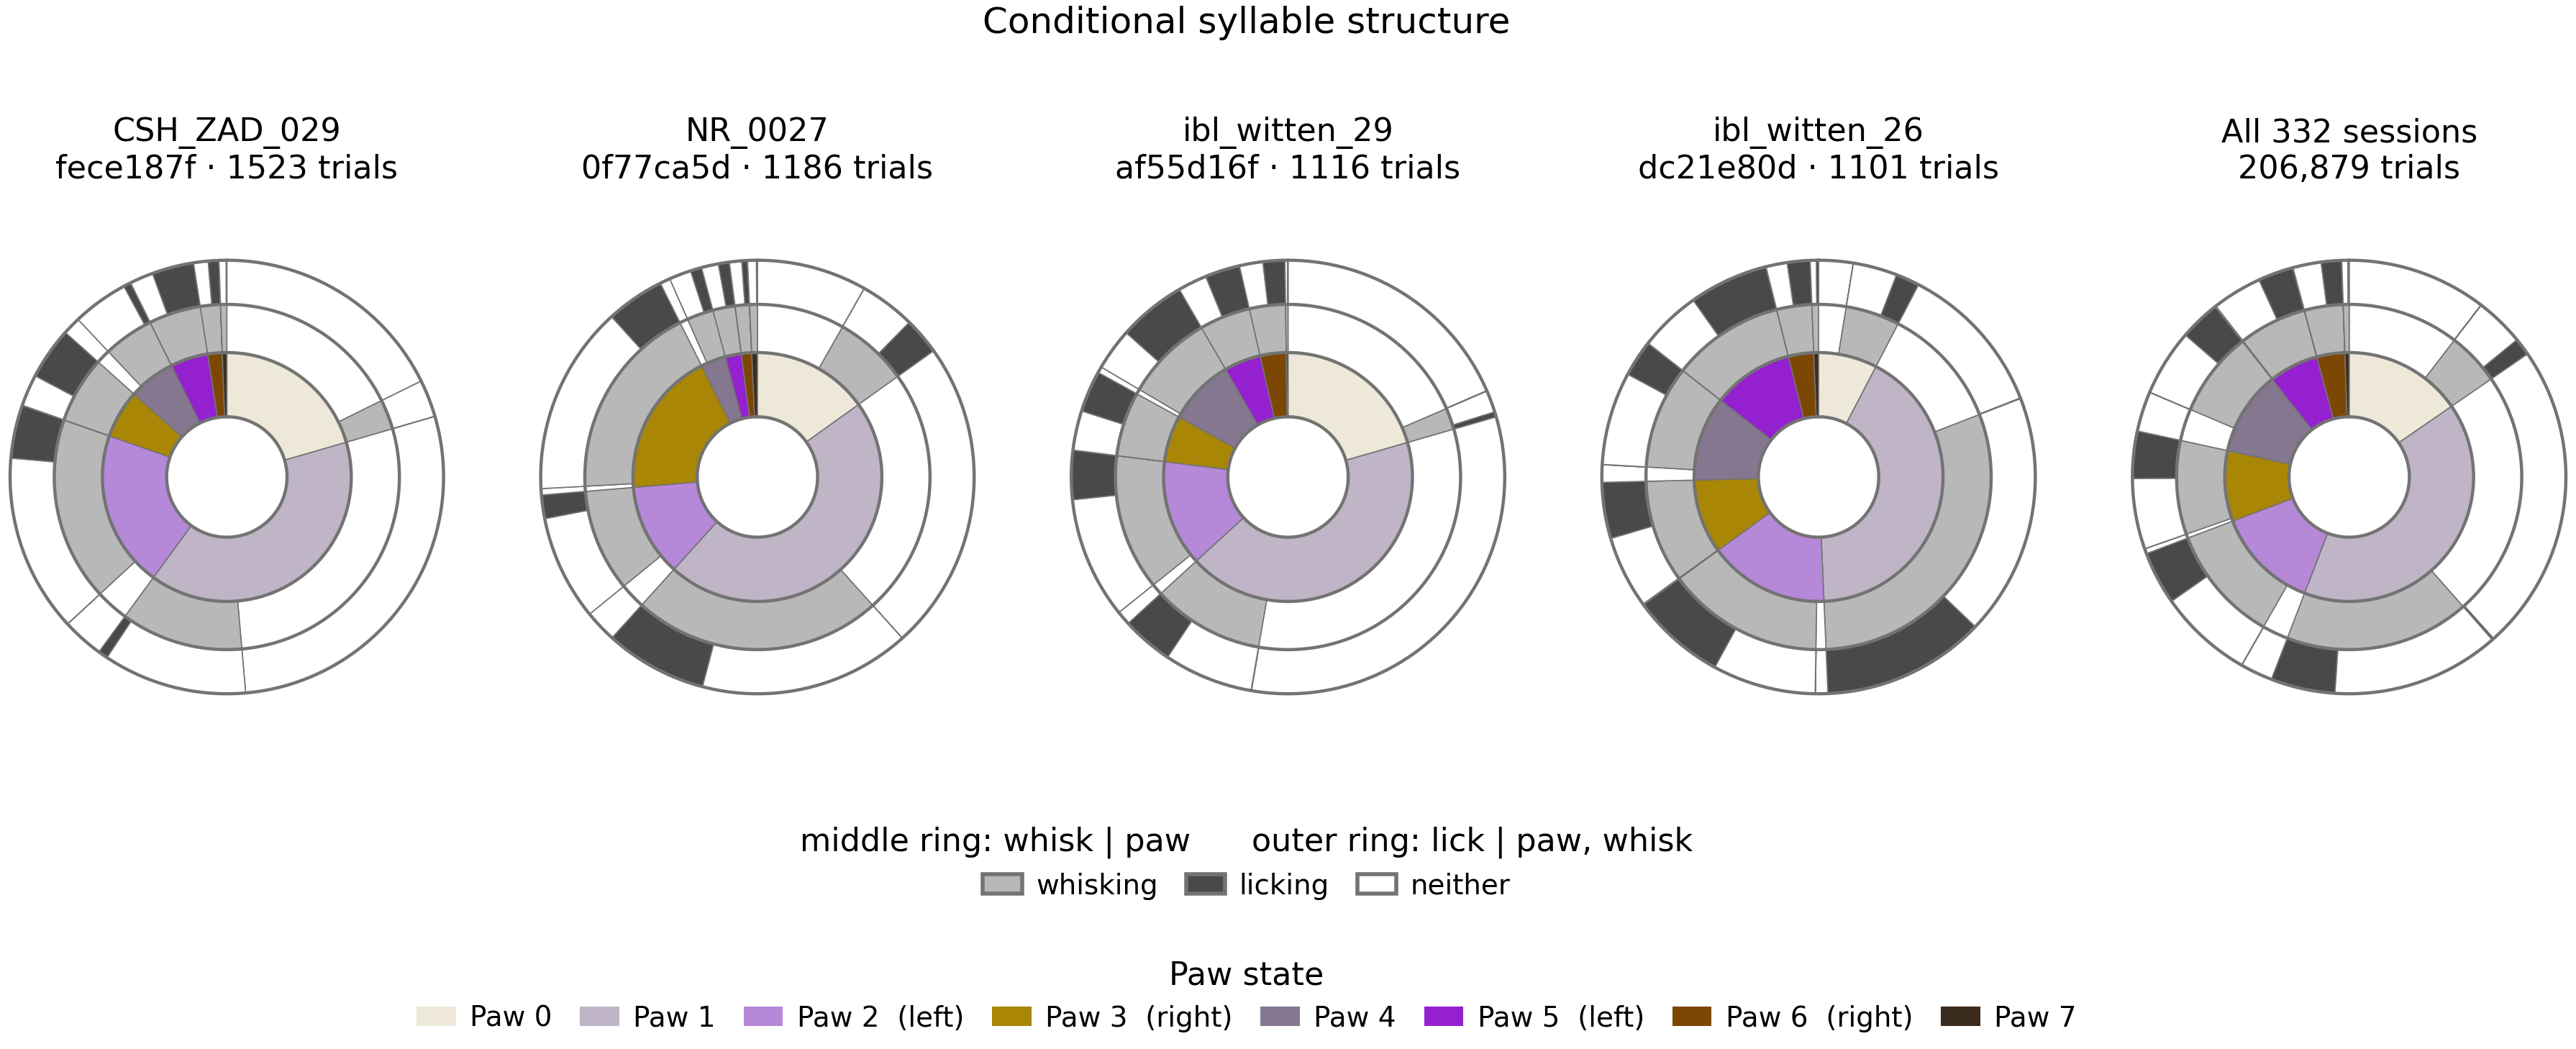

grand average
  P(paw)               [0.154 0.404 0.134 0.092 0.11  0.064 0.036 0.006]
  P(whisk | paw)       [0.322 0.428 0.818 0.958 0.727 0.987 0.994 0.993]
  P(lick | paw, whisk) [0.262 0.276 0.361 0.401 0.377 0.414 0.418 0.16 ]


In [ ]:
"""DONUTS -- one example session per mouse, plus the grand average."""
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, len(EXAMPLES) + 1, figsize=(2.3 * (len(EXAMPLES) + 1), 2.9),
                         subplot_kw={'projection': 'polar'})
for ax, (s, m, n, _) in zip(axes, EXAMPLES):
    syllable_donut(codes_for(seq[seq['session'] == s]), ax, f'{m}\n{s[:8]} · {int(n)} trials')
P_paw_all, P_w_all, P_l_all = syllable_donut(
    ALL_CODES, axes[-1], f'All {len(OCC)} sessions\n{len(ALL_CODES):,} trials')

fig.legend(handles=[Patch(facecolor=WHISK_RING_COLORS[1], edgecolor='0.45', label='whisking'),
                    Patch(facecolor=LICK_RING_COLORS[1], edgecolor='0.45', label='licking'),
                    Patch(facecolor='white', edgecolor='0.45', label='neither')],
           ncol=3, loc='upper center', bbox_to_anchor=(0.5, 0.10), frameon=False,
           title='middle ring: whisk | paw      outer ring: lick | paw, whisk')
# missing=False: NaN bins are excluded from the conditionals, so there is no
# 'no data' wedge to key here
ps.paw_legend(fig, ncol=8, missing=False, bbox_to_anchor=(0.5, -0.06))
fig.suptitle('Conditional syllable structure', y=1.06)
ps.savefig(fig, 'syllable_donut', svg=True)
plt.show()

print('grand average')
print('  P(paw)              ', np.round(P_paw_all, 3))
print('  P(whisk | paw)      ', np.round(P_w_all[:, 1], 3))
print('  P(lick | paw, whisk)', np.round(P_l_all[:, 1, 1], 3))


## Example trials in real time

Everything above is **time-warped**: each epoch is squeezed to 10 bins, so a column is a
*fraction through the epoch* rather than a moment. That is what makes trials of different
length averageable, and it is also what hides how long anything actually took.

These panels are the opposite. One row per trial, real seconds on the x axis, aligned to a
chosen event, with each trial's own landmarks drawn on its own row. Reference:
`1_segmentation/1_b.ipynb`, `plot_state_heatmap_trials`.

Two deliberate differences from that reference:

* **Native resolution.** It re-binned to 50 ms and took the mode. The states are already
  1/60 s, so the grid here is 1/60 s and each cell takes the sample falling in it — no mode,
  no smoothing, nothing invented.
* **Bins are selected by TIME, not by `trial_id`.** A window reaching back before the trial's
  own pre-quiescence would otherwise be blank, because those bins belong to the previous
  trial. Selecting on `Bin` shows the recording as it actually ran.

Note that paw state 0 is near-white (`#EDE8D8`) and a tracking dropout is pure white, so the
legend for these panels keys the dropout colour explicitly rather than using
`ps.paw_legend`'s hatched swatch, which `imshow` cannot draw.


In [ ]:
"""KNOBS AND LOADER FOR THE REAL-TIME STACKS."""
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Rectangle

N_EXAMPLE_TRIALS = 30      # rows per panel
TRIAL_START      = 40      # first trial of the contiguous block (not the mouse's first)
TIME_BEFORE      = 1.0     # seconds drawn before the alignment event
TIME_AFTER       = 2.5     # ... and after
ALIGN_TO         = 'goCueTrigger_times'   # any column of session_trials

STATES_DIR = STATES_FILES_DIR
TRIALS_DIR = ROOT + 'data/design_matrices/'
NODATA = 'white'
FEEDBACK_COLORS = {1: '#1B7F3B', -1: '#C0392B'}
EVENT_COLORS = {'quiescence start': '#111111', 'stim on': "#060707",
                'first movement': "#FCFBFC"}


def trial_stack(ax, session, mouse, n_trials=None, start=None, t0=None, t1=None,
                align=None, dt=1 / 60, texture=True):
    """One panel: paw state per trial over real time, with that trial's events."""
    n_trials = N_EXAMPLE_TRIALS if n_trials is None else n_trials
    start = TRIAL_START if start is None else start
    t0 = TIME_BEFORE if t0 is None else t0
    t1 = TIME_AFTER if t1 is None else t1
    align = ALIGN_TO if align is None else align

    st = pd.read_parquet(f'{STATES_DIR}8_states_file_{session}_{mouse}',
                         columns=['Bin', 'most_likely_states'])
    tr = (pd.read_parquet(f'{TRIALS_DIR}session_trials_{session}_{mouse}')
          .reset_index(drop=True).iloc[start:start + n_trials])
    bins = st['Bin'].to_numpy(float)
    code = ps.paw_codes(st['most_likely_states'].to_numpy(float))
    grid = np.arange(-t0, t1 + dt / 2, dt)

    M = np.full((len(tr), len(grid)), np.nan)
    for i, (_, row) in enumerate(tr.iterrows()):
        a = row[align]
        if not np.isfinite(a):
            continue
        lo, hi = np.searchsorted(bins, [a - t0, a + t1])
        idx = np.round((bins[lo:hi] - a + t0) / dt).astype(int)
        v = code[lo:hi]
        keep = (idx >= 0) & (idx < len(grid)) & np.isfinite(v)
        M[i, idx[keep]] = v[keep]

    paw, whisk, lick = ps.decode_syllables(M, N_STATES)
    cmap = ListedColormap(ps.PAW_STATE_COLORS)
    cmap.set_bad(NODATA)
    ax.imshow(np.ma.masked_invalid(paw), aspect='auto', cmap=cmap, vmin=-0.5,
              vmax=N_STATES - 0.5, interpolation='nearest',
              extent=[-t0, t1, len(tr) - 0.5, -0.5])

    # whisk/lick as ps.PAW_HATCH over the colour, as in syllable_histogram(texture=True).
    # imshow cannot hatch, so each run of constant (whisk, lick) within a row is one
    # transparent hatched patch; dropouts are left bare so they still read as white.
    if texture:
        cw = (t0 + t1) / len(grid)                     # column width in the extent's units
        wl = np.where(np.isnan(whisk), -1, whisk + 2 * lick)
        for i, r in enumerate(wl):
            cuts = np.flatnonzero(np.diff(r)) + 1
            for lo, hi in zip(np.r_[0, cuts], np.r_[cuts, len(r)]):
                if r[lo] <= 0:                         # neither, or no data
                    continue
                w, l = int(r[lo]) % 2, int(r[lo]) // 2
                ax.add_patch(Rectangle((-t0 + lo * cw, i - 0.5), (hi - lo) * cw, 1,
                                       facecolor='none', edgecolor='grey',
                                       hatch=ps.PAW_HATCH[(w, l)], linewidth=0))  #ps.HATCH_INK_DARK

    # alignment: a white halo under dark dashes, so it reads over any state colour
    ax.axvline(0, color='white', lw=1.8)
    ax.axvline(0, color='0.1', lw=0.7, ls=(0, (3, 2)))

    for i, (_, row) in enumerate(tr.iterrows()):
        a = row[align]

        def mark(t, c):
            if np.isfinite(t) and -t0 <= t - a <= t1:
                ax.plot([t - a, t - a], [i - 0.45, i + 0.45], color=c, lw=1.1,
                        solid_capstyle='butt')

        if np.isfinite(row.get('quiescencePeriod', np.nan)):
            mark(row['goCueTrigger_times'] - row['quiescencePeriod'],
                 EVENT_COLORS['quiescence start'])
        mark(row.get('stimOn_times', np.nan), EVENT_COLORS['stim on'])
        mark(row.get('firstMovement_times', np.nan), EVENT_COLORS['first movement'])
        fb = row.get('feedbackType', np.nan)
        if np.isfinite(fb):
            mark(row.get('feedback_times', np.nan), FEEDBACK_COLORS.get(int(fb), '0.4'))

    ax.set_xlabel(f'Time from {align.replace("Trigger_times", "").replace("_times", "")} (s)')
    ax.set_title(f'{mouse}\n{session[:8]} · trials {start}–{start + len(tr) - 1}',
                 fontsize=plt.rcParams['font.size'])
    return M


not saved (ps.SAVE_FIGURES is False): figures/syllable_example_trials_02-10-2026.png, figures/syllable_example_trials_02-10-2026.svg   -- ps.saving(True) to write, or pass save=True


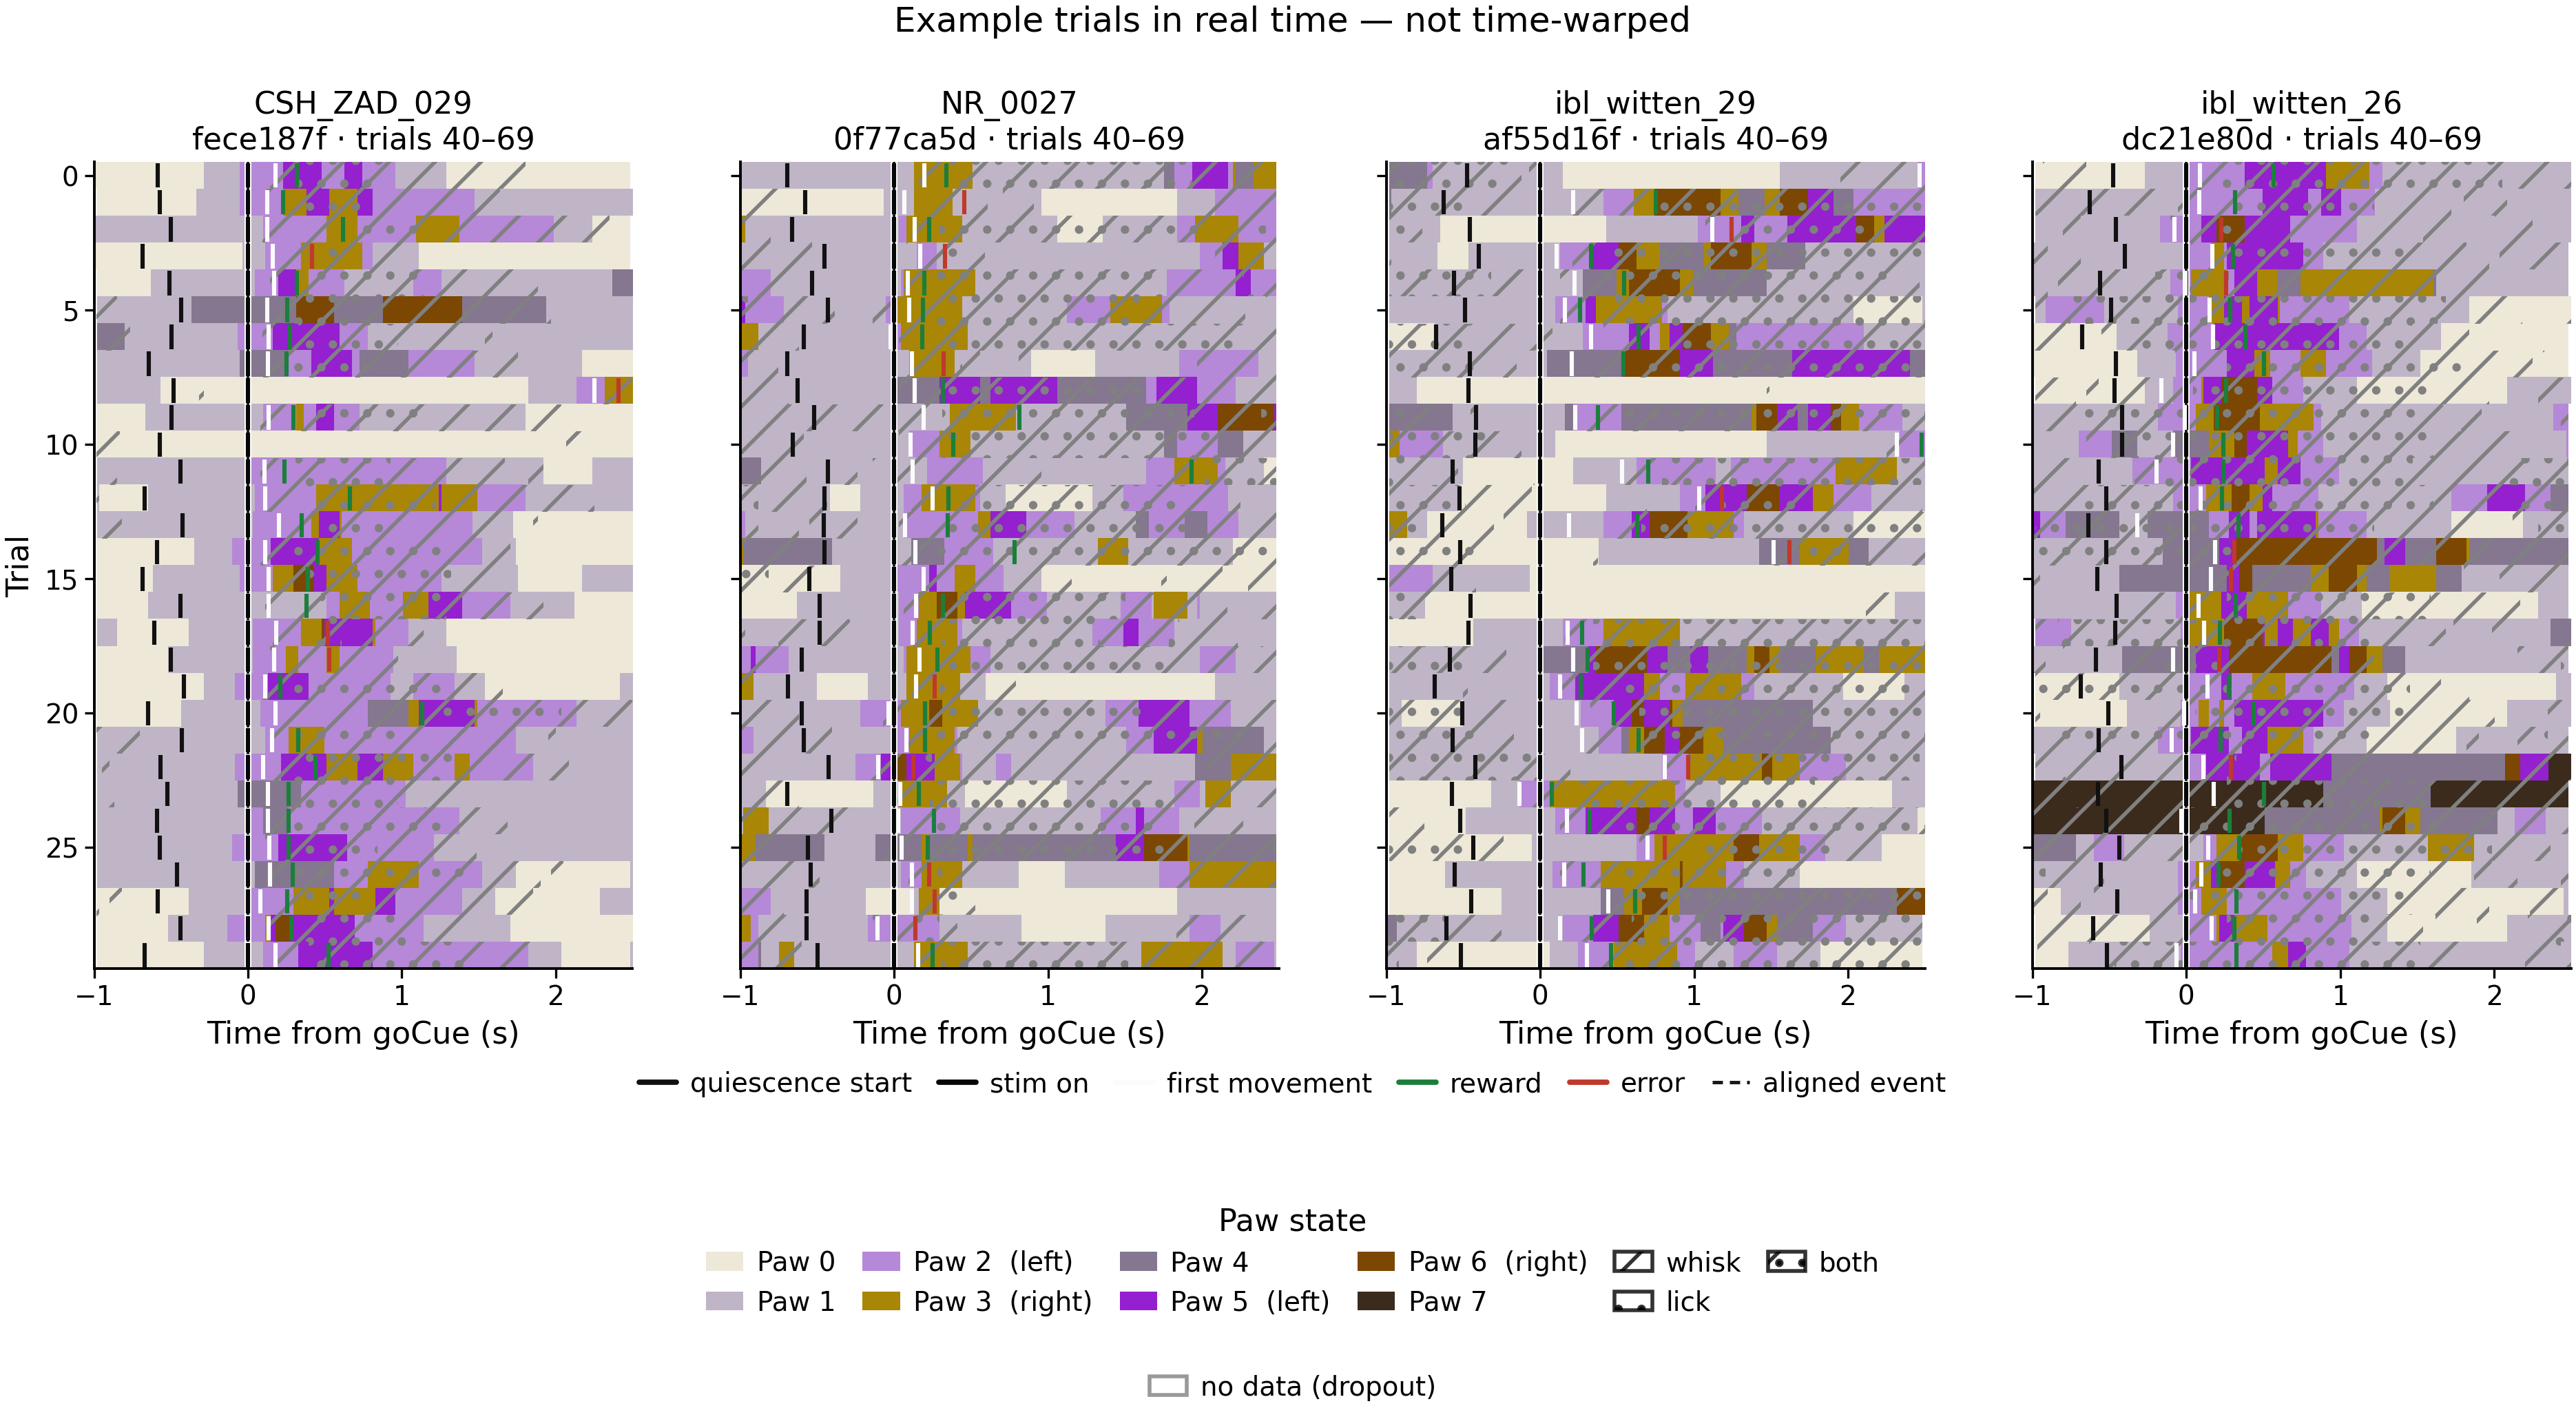

In [ ]:
"""FIGURE -- one example session per mouse, real time."""
fig, axes = plt.subplots(1, len(EXAMPLES), figsize=(2.9 * len(EXAMPLES), 3.8), sharey=True)
axes = np.atleast_1d(axes)
for ax, (s, m, _, _) in zip(axes, EXAMPLES):
    trial_stack(ax, s, m)
axes[0].set_ylabel('Trial')

_handles = [Line2D([], [], color=c, lw=1.4, label=k) for k, c in EVENT_COLORS.items()]
_handles += [Line2D([], [], color=FEEDBACK_COLORS[1], lw=1.4, label='reward'),
             Line2D([], [], color=FEEDBACK_COLORS[-1], lw=1.4, label='error'),
             Line2D([], [], color='0.1', lw=0.9, ls=(0, (3, 2)), label='aligned event')]
fig.legend(handles=_handles, ncol=6, loc='upper center', bbox_to_anchor=(0.5, 0.03),
           frameon=False)
# missing=False: imshow cannot hatch, so the dropout key is added here in the colour
# actually drawn rather than paper_style's hatched swatch
ps.paw_legend(fig, ncol=6, missing=False, hatch=True, bbox_to_anchor=(0.5, -0.10))
fig.legend(handles=[Patch(facecolor=NODATA, edgecolor='0.6', label='no data (dropout)')],
           ncol=1, loc='upper center', bbox_to_anchor=(0.5, -0.26), frameon=False)
fig.suptitle('Example trials in real time — not time-warped', y=1.03)
ps.savefig(fig, 'syllable_example_trials', svg=True)
plt.show()
